# Analyse des Données Olympiques

Ce notebook analyse 4 datasets olympiques dans différents formats :
- `olympic_athletes.json` (JSON)
- `olympic_hosts.xml` (XML)
- `olympic_medals.xlsx` (Excel)
- `olympic_results.html` (HTML)

## 1. Importation des Bibliothèques

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import xml.etree.ElementTree as ET
from bs4 import BeautifulSoup
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
import re
from unidecode import unidecode
import ast
import unicodedata

warnings.filterwarnings('ignore')

# Style sombre global: fond totalement noir et textes blancs
plt.style.use('dark_background')
# Palette code-style (vives)
code_palette = ['#ff79c6', '#8be9fd', '#50fa7b', '#f1fa8c', '#bd93f9', '#ffb86c']
sns.set_palette(code_palette)

# rcParams pour fond noir complet et textes blancs
plt.rcParams.update({
    'figure.facecolor': '#000000',    # fond figure -> noir
    'axes.facecolor': '#000000',      # fond axes -> noir
    'savefig.facecolor': '#000000',
    'figure.edgecolor': '#000000',
    'axes.edgecolor': '#44475a',
    'axes.labelcolor': 'white',
    'axes.titlecolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'legend.facecolor': '#000000',
    'legend.edgecolor': '#44475a',
    'legend.fontsize': 'medium',
    'grid.color': '#222427',
    'grid.alpha': 0.25,
    'axes.titleweight': 'bold',
    'font.size': 12
})

# Seaborn style dark with axis facecolor black
sns.set_style('dark', {'axes.facecolor': '#000000', 'grid.color': '#222427', 'text.color': 'white'})

# Ensure plotly uses dark template by default
try:
    px.defaults.template = 'plotly_dark'
except Exception:
    pass

# Affichage inline
%matplotlib inline

### 2.1 Dataset JSON - Athletes Olympiques

In [29]:
# Chargement du fichier JSON
with open('../data/raw/olympic_athletes.json', 'r', encoding='utf-8') as f:
    athletes_data = json.load(f)

# Conversion en DataFrame
df_athletes = pd.json_normalize(athletes_data)

print(f"Dataset Athletes - Shape: {df_athletes.shape}")
print(f"Colonnes: {list(df_athletes.columns)}")
df_athletes.head()

Dataset Athletes - Shape: (75904, 7)
Colonnes: ['athlete_url', 'athlete_full_name', 'games_participations', 'first_game', 'athlete_year_birth', 'athlete_medals', 'bio']


,athlete_url,athlete_full_name,games_participations,first_game,athlete_year_birth,athlete_medals,bio
0,https://olympics.com/en/athletes/cooper-woods-...,Cooper WOODS-TOPALOVIC,1,Beijing 2022,2000.0,None,None
1,https://olympics.com/en/athletes/elofsson,Felix ELOFSSON,2,PyeongChang 2018,1995.0,None,None
2,https://olympics.com/en/athletes/dylan-walczyk,Dylan WALCZYK,1,Beijing 2022,1993.0,None,None
3,https://olympics.com/en/athletes/olli-penttala,Olli PENTTALA,1,Beijing 2022,1995.0,None,None
4,https://olympics.com/en/athletes/reikherd,Dmitriy REIKHERD,1,Beijing 2022,1989.0,None,None


### 2.2 Dataset XML - Villes Hôtes

In [30]:
# Chargement et parsing du fichier XML
tree = ET.parse('../data/raw/olympic_hosts.xml')
root = tree.getroot()

# Extraction des données XML en DataFrame
hosts_data = []
for child in root:
    host_info = {}
    for elem in child:
        host_info[elem.tag] = elem.text
    hosts_data.append(host_info)

df_hosts = pd.DataFrame(hosts_data)

print(f"Dataset Hosts - Shape: {df_hosts.shape}")
print(f"Colonnes: {list(df_hosts.columns)}")
df_hosts.head()

Dataset Hosts - Shape: (53, 8)
Colonnes: ['index', 'game_slug', 'game_end_date', 'game_start_date', 'game_location', 'game_name', 'game_season', 'game_year']


,index,game_slug,game_end_date,game_start_date,game_location,game_name,game_season,game_year
0,0,beijing-2022,2022-02-20T12:00:00Z,2022-02-04T15:00:00Z,China,Beijing 2022,Winter,2022
1,1,tokyo-2020,2021-08-08T14:00:00Z,2021-07-23T11:00:00Z,Japan,Tokyo 2020,Summer,2020
2,2,pyeongchang-2018,2018-02-25T08:00:00Z,2018-02-08T23:00:00Z,Republic of Korea,PyeongChang 2018,Winter,2018
3,3,rio-2016,2016-08-21T21:00:00Z,2016-08-05T12:00:00Z,Brazil,Rio 2016,Summer,2016
4,4,sochi-2014,2014-02-23T16:00:00Z,2014-02-07T04:00:00Z,Russian Federation,Sochi 2014,Winter,2014


### 2.3 Dataset Excel - Médailles

In [31]:
# Chargement du fichier Excel
df_medals = pd.read_excel('../data/raw/olympic_medals.xlsx')

print(f"Dataset Medals - Shape: {df_medals.shape}")
print(f"Colonnes: {list(df_medals.columns)}")
df_medals.head()

Dataset Medals - Shape: (21697, 13)
Colonnes: ['Unnamed: 0', 'discipline_title', 'slug_game', 'event_title', 'event_gender', 'medal_type', 'participant_type', 'participant_title', 'athlete_url', 'athlete_full_name', 'country_name', 'country_code', 'country_3_letter_code']


,Unnamed: 0,discipline_title,slug_game,event_title,event_gender,medal_type,participant_type,participant_title,athlete_url,athlete_full_name,country_name,country_code,country_3_letter_code
0,0,Curling,beijing-2022,Mixed Doubles,Mixed,GOLD,GameTeam,Italy,https://olympics.com/en/athletes/stefania-cons...,Stefania CONSTANTINI,Italy,IT,ITA
1,1,Curling,beijing-2022,Mixed Doubles,Mixed,GOLD,GameTeam,Italy,https://olympics.com/en/athletes/amos-mosaner,Amos MOSANER,Italy,IT,ITA
2,2,Curling,beijing-2022,Mixed Doubles,Mixed,SILVER,GameTeam,Norway,https://olympics.com/en/athletes/kristin-skaslien,Kristin SKASLIEN,Norway,NO,NOR
3,3,Curling,beijing-2022,Mixed Doubles,Mixed,SILVER,GameTeam,Norway,https://olympics.com/en/athletes/magnus-nedreg...,Magnus NEDREGOTTEN,Norway,NO,NOR
4,4,Curling,beijing-2022,Mixed Doubles,Mixed,BRONZE,GameTeam,Sweden,https://olympics.com/en/athletes/almida-de-val,Almida DE VAL,Sweden,SE,SWE


### 2.4 Dataset HTML - Résultats

In [32]:
# Chargement et parsing du fichier HTML
with open('../data/raw/olympic_results.html', 'r', encoding='utf-8') as f:
    html_content = f.read()

soup = BeautifulSoup(html_content, 'html.parser')

# Extraction des tableaux HTML
tables = pd.read_html(str(soup))
df_results = tables[0] if tables else pd.DataFrame()

print(f"Dataset Results - Shape: {df_results.shape}")
print(f"Colonnes: {list(df_results.columns)}")
df_results.head()

Dataset Results - Shape: (162804, 16)
Colonnes: ['Unnamed: 0', 'discipline_title', 'event_title', 'slug_game', 'participant_type', 'medal_type', 'athletes', 'rank_equal', 'rank_position', 'country_name', 'country_code', 'country_3_letter_code', 'athlete_url', 'athlete_full_name', 'value_unit', 'value_type']


,Unnamed: 0,discipline_title,event_title,slug_game,participant_type,medal_type,athletes,rank_equal,rank_position,country_name,country_code,country_3_letter_code,athlete_url,athlete_full_name,value_unit,value_type
0,0,Curling,Mixed Doubles,beijing-2022,GameTeam,GOLD,"[('Stefania CONSTANTINI', 'https://olympics.co...",False,1,Italy,IT,ITA,NaN,NaN,NaN,NaN
1,1,Curling,Mixed Doubles,beijing-2022,GameTeam,SILVER,"[('Kristin SKASLIEN', 'https://olympics.com/en...",False,2,Norway,NO,NOR,NaN,NaN,NaN,NaN
2,2,Curling,Mixed Doubles,beijing-2022,GameTeam,BRONZE,"[('Almida DE VAL', 'https://olympics.com/en/at...",False,3,Sweden,SE,SWE,NaN,NaN,NaN,NaN
3,3,Curling,Mixed Doubles,beijing-2022,GameTeam,NaN,"[('Jennifer DODDS', 'https://olympics.com/en/a...",False,4,Great Britain,GB,GBR,NaN,NaN,NaN,NaN
4,4,Curling,Mixed Doubles,beijing-2022,GameTeam,NaN,"[('Rachel HOMAN', 'https://olympics.com/en/ath...",False,5,Canada,CA,CAN,NaN,NaN,NaN,NaN


## 3. Exploration des Données

### 3.1 Informations Générales

In [33]:
# Résumé des datasets
datasets = {
    'Athletes (JSON)': df_athletes,
    'Hosts (XML)': df_hosts,
    'Medals (Excel)': df_medals,
    'Results (HTML)': df_results
}

for name, df in datasets.items():
    print(f"\n=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Colonnes: {list(df.columns)}")
    print(f"Types de données:")
    print(df.dtypes)
    print(f"Valeurs manquantes: {df.isnull().sum().sum()}")


=== Athletes (JSON) ===
Shape: (75904, 7)
Colonnes: ['athlete_url', 'athlete_full_name', 'games_participations', 'first_game', 'athlete_year_birth', 'athlete_medals', 'bio']
Types de données:
athlete_url              object
athlete_full_name        object
games_participations      int64
first_game               object
athlete_year_birth      float64
athlete_medals           object
bio                      object
dtype: object
Valeurs manquantes: 116092

=== Hosts (XML) ===
Shape: (53, 8)
Colonnes: ['index', 'game_slug', 'game_end_date', 'game_start_date', 'game_location', 'game_name', 'game_season', 'game_year']
Types de données:
index              object
game_slug          object
game_end_date      object
game_start_date    object
game_location      object
game_name          object
game_season        object
game_year          object
dtype: object
Valeurs manquantes: 0

=== Medals (Excel) ===
Shape: (21697, 13)
Colonnes: ['Unnamed: 0', 'discipline_title', 'slug_game', 'event_title', '

### 3.2 Statistiques Descriptives

In [34]:
# Statistiques descriptives pour chaque dataset
for name, df in datasets.items():
    print(f"\n=== Statistiques pour {name} ===")
    print(df.describe())


=== Statistiques pour Athletes (JSON) ===
       games_participations  athlete_year_birth
count          75904.000000        73448.000000
mean               1.535874         1961.619377
std                0.854563           28.129576
min                0.000000         1836.000000
25%                1.000000         1946.000000
50%                1.000000         1968.000000
75%                2.000000         1983.000000
max               10.000000         2009.000000

=== Statistiques pour Hosts (XML) ===
       index     game_slug         game_end_date       game_start_date  \
count     53            53                    53                    53   
unique    53            53                    53                    53   
top        0  beijing-2022  2022-02-20T12:00:00Z  2022-02-04T15:00:00Z   
freq       1             1                     1                     1   

        game_location     game_name game_season game_year  
count              53            53          53        

## 4. Visualisations Préliminaires

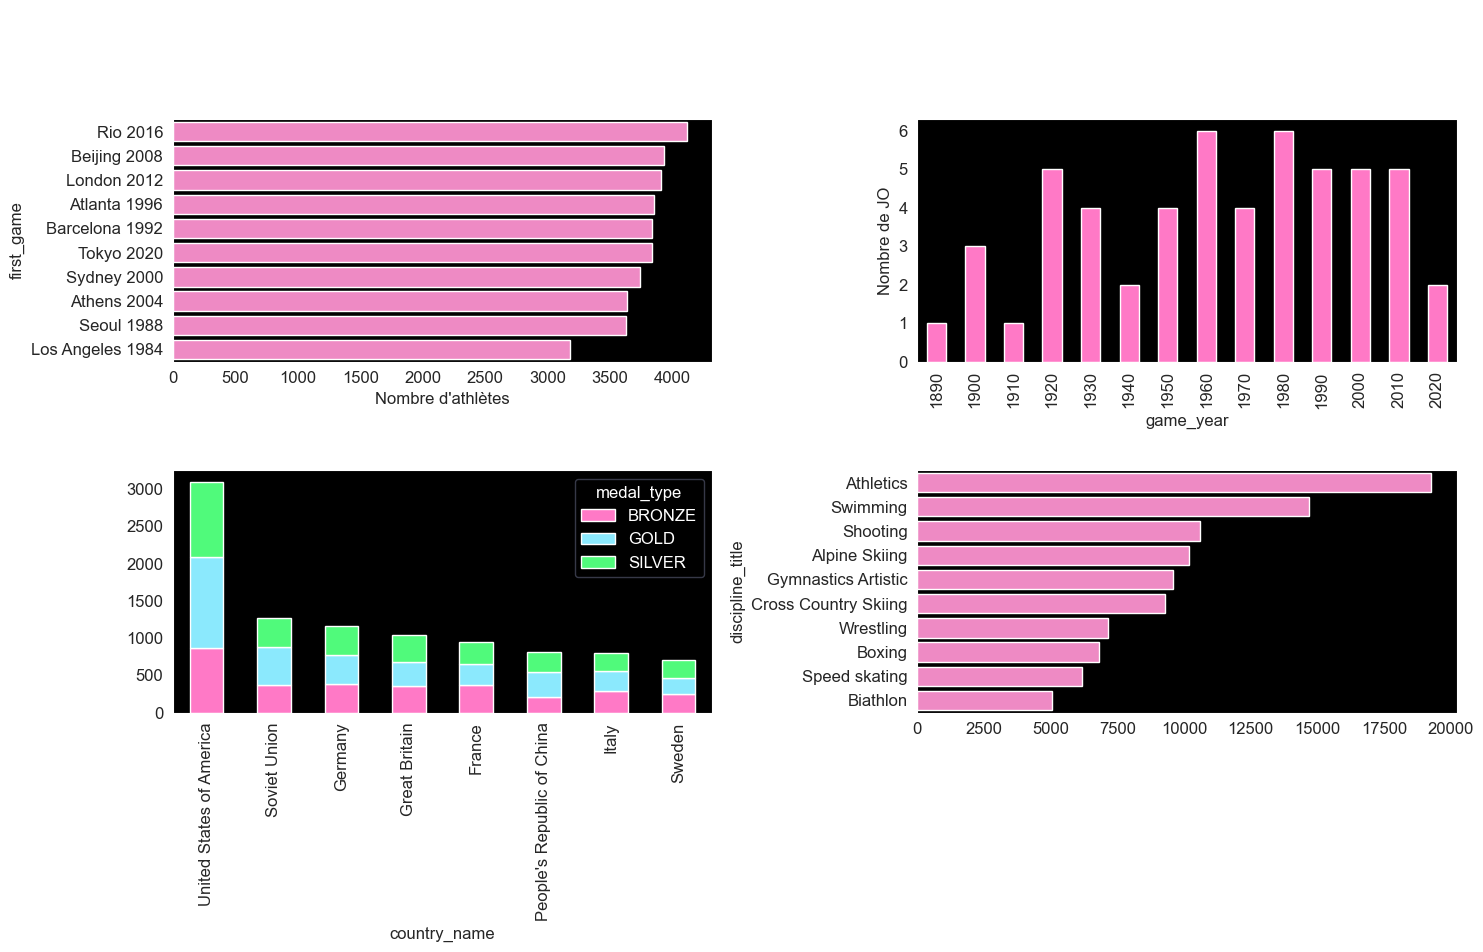

In [35]:
# Configuration des sous-graphiques
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Aperçu des Datasets Olympiques', fontsize=16, fontweight='bold')
axes_flat = axes.ravel()

# 1) Athletes - Top 10 par première participation (first_game)
try:
    if 'first_game' in df_athletes.columns:
        top = df_athletes['first_game'].value_counts().nlargest(10)
        sns.barplot(x=top.values, y=top.index, ax=axes_flat[0])
        axes_flat[0].set_title('Top 10 - Première participation (games)')
        axes_flat[0].set_xlabel("Nombre d'athlètes")
    else:
        axes_flat[0].text(0.5, 0.5, 'Colonne first_game introuvable', ha='center')
except Exception as e:
    axes_flat[0].text(0.5, 0.5, f'Erreur: {e}', ha='center')

# 2) Hosts - Répartition des JO par décennie
try:
    if 'game_year' in df_hosts.columns:
        years = pd.to_numeric(df_hosts['game_year'], errors='coerce')
        decades = (years // 10 * 10).dropna().astype(int)
        host_counts = decades.value_counts().sort_index()
        host_counts.plot(kind='bar', ax=axes_flat[1])
        axes_flat[1].set_title('JO par décennie (hôtes)')
        axes_flat[1].set_ylabel('Nombre de JO')
    else:
        axes_flat[1].text(0.5, 0.5, 'game_year introuvable', ha='center')
except Exception as e:
    axes_flat[1].text(0.5, 0.5, f'Erreur: {e}', ha='center')

# 3) Medals - Répartition par type de médaille (Or/Argent/Bronze) pour les top pays
try:
    if 'medal_type' in df_medals.columns and 'country_name' in df_medals.columns:
        medal_counts = df_medals.groupby(['country_name', 'medal_type']).size().unstack(fill_value=0)
        top_countries = medal_counts.sum(axis=1).nlargest(8).index
        medal_counts.loc[top_countries].plot(kind='bar', stacked=True, ax=axes_flat[2])
        axes_flat[2].set_title('Médailles par type - Top pays')
    else:
        axes_flat[2].text(0.5, 0.5, 'Colonnes medal_type/country_name introuvables', ha='center')
except Exception as e:
    axes_flat[2].text(0.5, 0.5, f'Erreur: {e}', ha='center')

# 4) Results - Top disciplines
try:
    if 'discipline_title' in df_results.columns:
        top_sports = df_results['discipline_title'].value_counts().nlargest(10)
        sns.barplot(x=top_sports.values, y=top_sports.index, ax=axes_flat[3])
        axes_flat[3].set_title('Top 10 disciplines - Résultats')
    else:
        axes_flat[3].text(0.5, 0.5, 'discipline_title introuvable', ha='center')
except Exception as e:
    axes_flat[3].text(0.5, 0.5, f'Erreur: {e}', ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [36]:
# Cellule: Nettoyage / Standardisation / Structuration
# Cette cellule effectue des opérations de nettoyage légères et de standardisation
# sur les DataFrame chargés précédemment : `df_hosts`, `df_medals`, `df_results`, `df_athletes`.
# Elle est volontairement conservatrice (ne modifie pas les colonnes originales sans doublons)
# et crée des colonnes canonicales pour faciliter les analyses suivantes.

import numpy as np
import pandas as pd
from IPython.display import display

# --- Fonctions utilitaires de normalisation (commentées en français) ---

def normalize_gender(value):
    """Normalise différentes notations de genre en : 'Men', 'Women', 'Mixed', 'Other' ou NaN.
    On cherche des tokens courants (english/français) et des indicateurs comme 'open' ou 'mixed'.
    """
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s == '':
        return np.nan
    # tokens masculins
    if any(tok in s for tok in ['men', "men's", 'man', 'm', 'masculin', 'male']):
        return 'Men'
    # tokens féminins
    if any(tok in s for tok in ['women', "women's", 'woman', 'f', 'feminin', 'female', 'femme', 'ladies']):
        return 'Women'
    # tokens mixtes / ouverts / équipes
    if any(tok in s for tok in ['mixed', 'open', 'team', 'coed', 'mixed-sex']):
        return 'Mixed'
    # cas explicites
    if s in ['male/female', 'x', 'other', 'n/a', 'na', 'unknown']:
        return 'Other'
    # fallback : marquer Other pour inspection
    return 'Other'


def clean_country_name(s):
    """Nettoyage basique des noms de pays : strip, normaliser les espaces et capitalisation minimale.
    On ne fait pas de correspondance géographique complète (pas de dépendance externe).
    """
    if pd.isna(s):
        return ''
    return ' '.join(str(s).strip().split()).title()


# --- Appliquer les transformations par DataFrame (si présents) ---

# df_medals : normaliser le genre et nettoyer pays/noms
if 'df_medals' in globals():
    df_medals = globals()['df_medals']
    # conserver l'original si besoin
    if 'event_gender' in df_medals.columns:
        df_medals['event_gender_orig'] = df_medals['event_gender'].astype(object)
        df_medals['gender_canonical'] = df_medals['event_gender_orig'].apply(normalize_gender)
    else:
        df_medals['gender_canonical'] = np.nan

    if 'country_name' in df_medals.columns:
        df_medals['country_name_clean'] = df_medals['country_name'].apply(clean_country_name)
    if 'country_code' in df_medals.columns:
        df_medals['country_code_clean'] = df_medals['country_code'].astype(str).str.strip().str.upper().replace({'nan':''})
    if 'athlete_full_name' in df_medals.columns:
        df_medals['athlete_name_clean'] = df_medals['athlete_full_name'].astype(str).str.replace('\s+', ' ', regex=True).str.strip()
    # supprimer doublons exacts (sûr)
    before = len(df_medals)
    df_medals.drop_duplicates(inplace=True)
    after = len(df_medals)

# df_results : essayer d'homogénéiser le genre (si présent) et nettoyer champs utiles
if 'df_results' in globals():
    df_results = globals()['df_results']
    if 'event_gender' in df_results.columns:
        df_results['event_gender_orig'] = df_results['event_gender'].astype(object)
        df_results['gender_canonical'] = df_results['event_gender_orig'].apply(normalize_gender)
    else:
        # tentative d'inférence minimale depuis le titre de l'épreuve
        df_results['gender_canonical'] = df_results.get('event_title', '').fillna('').astype(str).str.lower().apply(
            lambda s: 'Women' if any(t in s for t in ['women', "women's", 'ladies', 'fem']) else ('Men' if any(t in s for t in ['men', "men's"]) else ( 'Mixed' if any(t in s for t in ['mixed','open']) else np.nan))
        )

    if 'country_name' in df_results.columns:
        df_results['country_name_clean'] = df_results['country_name'].apply(clean_country_name)
    if 'athlete_full_name' in df_results.columns:
        df_results['athlete_name_clean'] = df_results['athlete_full_name'].astype(str).str.replace('\s+', ' ', regex=True).str.strip()
    if 'rank_position' in df_results.columns:
        df_results['rank_position_int'] = pd.to_numeric(df_results['rank_position'], errors='coerce').astype('Int64')

# df_hosts : parser les dates et assurer game_year entier
if 'df_hosts' in globals():
    df_hosts = globals()['df_hosts']
    for c in ['game_start_date','game_end_date']:
        if c in df_hosts.columns:
            df_hosts[c+'_parsed'] = pd.to_datetime(df_hosts[c], errors='coerce')
    if 'game_year' in df_hosts.columns:
        df_hosts['game_year_int'] = pd.to_numeric(df_hosts['game_year'], errors='coerce').astype('Int64')
    if 'game_location' in df_hosts.columns:
        df_hosts['game_location_clean'] = df_hosts['game_location'].apply(clean_country_name)

# df_athletes : nettoyage des noms et année de naissance
if 'df_athletes' in globals():
    df_athletes = globals()['df_athletes']
    if 'athlete_full_name' in df_athletes.columns:
        df_athletes['athlete_name_clean'] = df_athletes['athlete_full_name'].astype(str).str.replace('\s+', ' ', regex=True).str.strip()
    if 'athlete_year_birth' in df_athletes.columns:
        df_athletes['athlete_year_birth_int'] = pd.to_numeric(df_athletes['athlete_year_birth'], errors='coerce').astype('Int64')

# --- Résumé de vérification ---
print('\n=== Résumé rapide du nettoyage / canonicalisation ===')
for name in ['df_hosts','df_medals','df_results','df_athletes']:
    if name in globals():
        d = globals()[name]
        print(f"\n{name} : shape = {d.shape}")
        if 'gender_canonical' in d.columns:
            print(' gender_canonical counts:')
            print(d['gender_canonical'].value_counts(dropna=False).to_string())
        if 'country_name_clean' in d.columns:
            print(' top country_name_clean:')
            print(d['country_name_clean'].value_counts().head(5).to_string())
        if name == 'df_medals':
            print(f" doublons supprimés (approx) : {before - after if 'before' in locals() and 'after' in locals() else 'N/A'}")

# Exemple : afficher quelques lignes classées 'Other' dans df_medals pour inspection
if 'df_medals' in globals() and 'gender_canonical' in df_medals.columns:
    other = df_medals[df_medals['gender_canonical']=='Other']
    if len(other) > 0:
        print('\nExemples (max 10) de lignes df_medals classées comme "Other" (à inspecter) :')
        display(other[['event_title','event_gender','gender_canonical','athlete_full_name','country_name']].head(10))

print('\nNettoyage: FIN')



=== Résumé rapide du nettoyage / canonicalisation ===

df_hosts : shape = (53, 12)

df_medals : shape = (21697, 18)
 gender_canonical counts:
gender_canonical
Men      20699
Mixed      998
 top country_name_clean:
country_name_clean
United States Of America    3094
Soviet Union                1272
Germany                     1167
Great Britain               1045
France                       952
 doublons supprimés (approx) : 0

df_results : shape = (162804, 20)
 gender_canonical counts:
gender_canonical
Men      107537
Women     46044
Mixed      8348
NaN         875
 top country_name_clean:
country_name_clean
United States Of America    11916
France                       7552
Great Britain                6446
Italy                        6309
Germany                      5824

df_athletes : shape = (75904, 9)

Nettoyage: FIN


## 5. Questions d'Analyse

### 5.1 Vérification d'Événements Marquants aux JO

#### Question 1: La France a organisé 6 JO : 3 d'hiver et 3 d'été (en comptant celui de 2024) ?

##### Non la France n'as organisé que 5 JO, deux d'été et 3 d'hiver, Voici le code en dessous qui jusitifi

Top hosts (par nombre total d'organisations):
game_season    total
game_location       
United States      8
France             5
Japan              4
Italy              3
Great Britain      3
Canada             3
China              2
Austria            2
Norway             2
Greece             2
France - Summer: 2, Winter: 3, Total: 5


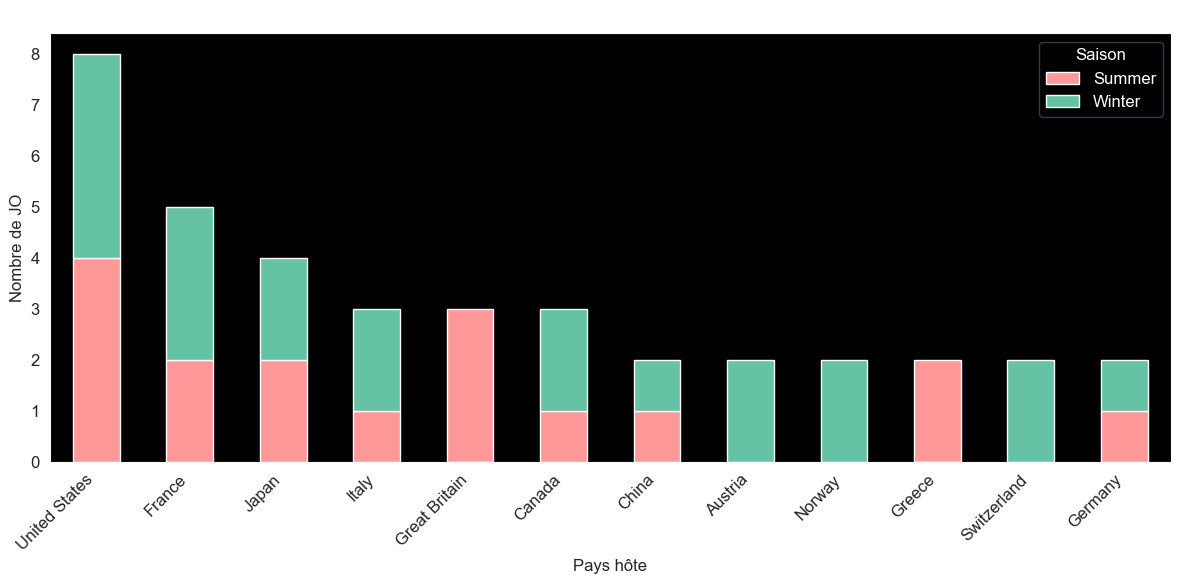

In [37]:
# Compter le nombre de fois où chaque pays a été hôte, séparé été/hiver
hosts = df_hosts.copy()
# On s'appuie sur 'game_location' (pays) et 'game_season' ('Summer'/'Winter')
counts = hosts.groupby(['game_location','game_season']).size().unstack(fill_value=0)
# Ajouter une colonne total pour trier
counts['total'] = counts.sum(axis=1)
counts = counts.sort_values('total', ascending=False)
print('Top hosts (par nombre total d\'organisations):')
print(counts[['total']].head(10))

# Tracer un bar empilé été vs hiver pour les top N pays
top_n = 12
top = counts.head(top_n).drop(columns='total')

ax = top.plot(kind='bar', stacked=True, figsize=(12,6), color=['#ff9999', '#66c2a5'])
ax.set_title("Nombre d'organisations par pays (été vs hiver) - top "+str(top_n))
ax.set_ylabel('Nombre de JO')
ax.set_xlabel('Pays hôte')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Saison')
plt.tight_layout()

# Afficher le détail pour la France si présente
if 'France' in counts.index:
    f = counts.loc['France']
    print('France - Summer: {}, Winter: {}, Total: {}'.format(int(f.get('Summer',0)), int(f.get('Winter',0)), int(f.get('total',0))))
else:
    print('France non trouvée dans le dataset des hôtes')

plt.show()


#### Question 2: La France est le 2è pays qui a organisé le plus de JO après les USA (8 JO) ?

##### Oui, on peut voir sur le graphique d'avant que la France est bien le 2ème pays ayant organisé le plus de Jeux Olympiques.

#### Question 3: Les JO d'hiver sont nés à Chamonix en 1924 ?

##### Non les Jo sont nées à Athenne en 1896

Premier JO d'hiver trouvé: Chamonix 1924 - France (1924)


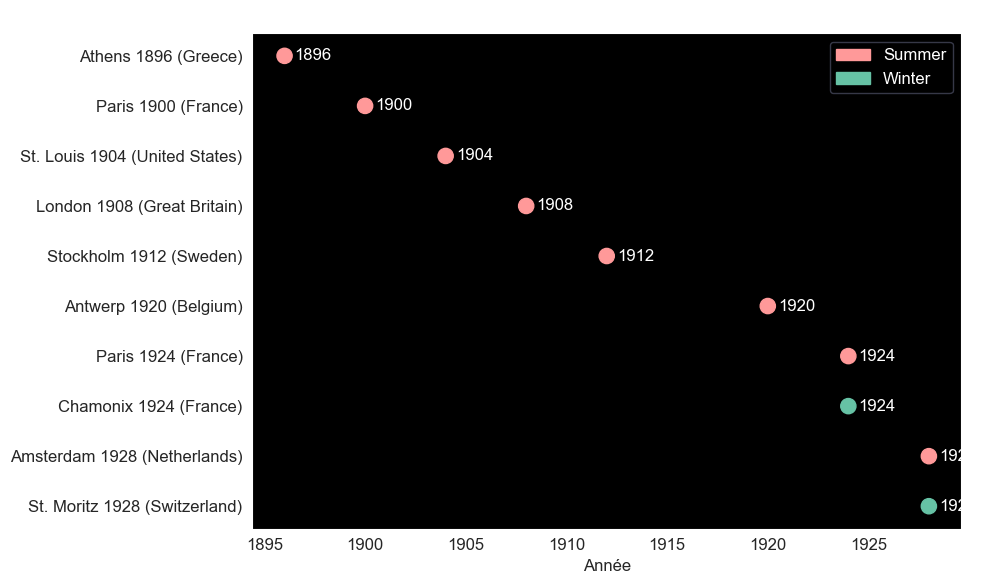

In [38]:
hosts = df_hosts.copy()
# Normaliser types
hosts['game_year'] = pd.to_numeric(hosts['game_year'], errors='coerce')
hosts['game_season'] = hosts['game_season'].astype(str)

# Trouver le premier JO d'hiver
first_winter = hosts[hosts['game_season'].str.lower() == 'winter'].sort_values('game_year').head(1)
if not first_winter.empty:
    row = first_winter.iloc[0]
    print(f"Premier JO d'hiver trouvé: {row.get('game_name','')} - {row.get('game_location','')} ({int(row.get('game_year'))})")
else:
    print('Aucun JO d\'hiver trouvé dans le dataset')

# Tracer les 10 premières éditions (par année) avec couleur été/hiver
first10 = hosts.sort_values('game_year').head(10).copy()
first10['color'] = first10['game_season'].map(lambda s: '#66c2a5' if str(s).lower() == 'winter' else '#ff9999')

import matplotlib.patches as mpatches

plt.figure(figsize=(10,6))
y = range(len(first10))
plt.scatter(first10['game_year'], y, c=first10['color'], s=120)
plt.yticks(y, first10['game_name'] + ' (' + first10['game_location'] + ')')
plt.gca().invert_yaxis()
plt.xlabel('Année')
plt.title("Emplacements des 10 premières éditions des JO (avec saison)")
# légende
winter_patch = mpatches.Patch(color='#66c2a5', label='Winter')
summer_patch = mpatches.Patch(color='#ff9999', label='Summer')
plt.legend(handles=[summer_patch, winter_patch])
# Annoter l'année à droite des points
for i, yr in enumerate(first10['game_year']):
    plt.text(yr + 0.5, i, str(int(yr)), va='center')

plt.tight_layout()
plt.show()


#### Question 4: JO de Paris, en 1900 : les femmes peuvent participer aux JO ?

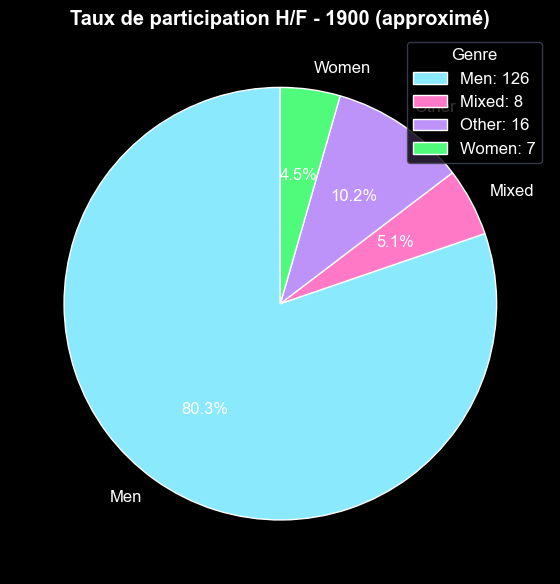

In [39]:
medals = df_medals.copy()
hosts_map = df_hosts[['game_slug','game_year']].drop_duplicates()
medals = medals.merge(hosts_map, left_on='slug_game', right_on='game_slug', how='left')
# s'assurer que game_year est numérique
medals['game_year'] = pd.to_numeric(medals['game_year'], errors='coerce')

subset = medals[medals['game_year'] == 1900]
if subset.empty:
    print('Aucune donnée pour 1900 trouvée dans df_medals (impossible de calculer le taux).')
else:
    # Normaliser la colonne de genre si elle existe
    if 'event_gender' in subset.columns:
        genders = subset['event_gender'].fillna('Unknown').astype(str)
    else:
        # fallback: essayer participant_type ou participant_title
        fallback = None
        for c in ['participant_type','participant_title']:
            if c in subset.columns:
                fallback = c
                break
        if fallback:
            genders = subset[fallback].fillna('Unknown').astype(str)
        else:
            genders = pd.Series(['Unknown'] * len(subset))

    def normalize_gender(x):
        s = str(x).lower()
        if 'woman' in s or 'female' in s or s.strip() in ('f','women'):
            return 'Women'
        if 'man' in s or 'male' in s or s.strip() in ('m','men'):
            return 'Men'
        if 'mix' in s:
            return 'Mixed'
        return 'Other'

    subset['gender_norm'] = genders.map(normalize_gender)

    # Nombre unique d'athlètes par genre (évite double comptage)
    if 'athlete_full_name' in subset.columns:
        counts = subset.groupby('gender_norm')['athlete_full_name'].nunique()
    else:
        counts = subset['gender_norm'].value_counts()

    counts = counts.sort_index()

    # Préparer le graphique camembert
    labels = counts.index.tolist()
    sizes = counts.values.tolist()

    # Couleurs (utiliser la palette code-style)
    palette = ['#8be9fd', '#ff79c6', '#bd93f9', '#50fa7b']
    # Ajuster longueur
    colors = [palette[i % len(palette)] for i in range(len(labels))]

    plt.figure(figsize=(6,6), facecolor='#000000')
    wedges, texts, autotexts = plt.pie(sizes, labels=labels, colors=colors,
                                       autopct='%1.1f%%', startangle=90, textprops={'color':'white'})
    # Rendre les labels en blanc
    for t in texts:
        t.set_color('white')
    for a in autotexts:
        a.set_color('white')

    plt.title('Taux de participation H/F - 1900 (approximé)', color='white')
    plt.legend(wedges, [f"{l}: {v}" for l,v in zip(labels,sizes)], title='Genre', facecolor='#000000', edgecolor='#44475a', labelcolor='white')
    plt.tight_layout()
    plt.show()


#### Question 5: Seuls 4 athlètes ont remporté des médailles à la fois aux JO d'hiver et d'été. Une seule d'entre eux, Christa Ludinger-Rothenburger, a remporté des médailles au cours de la même année ?

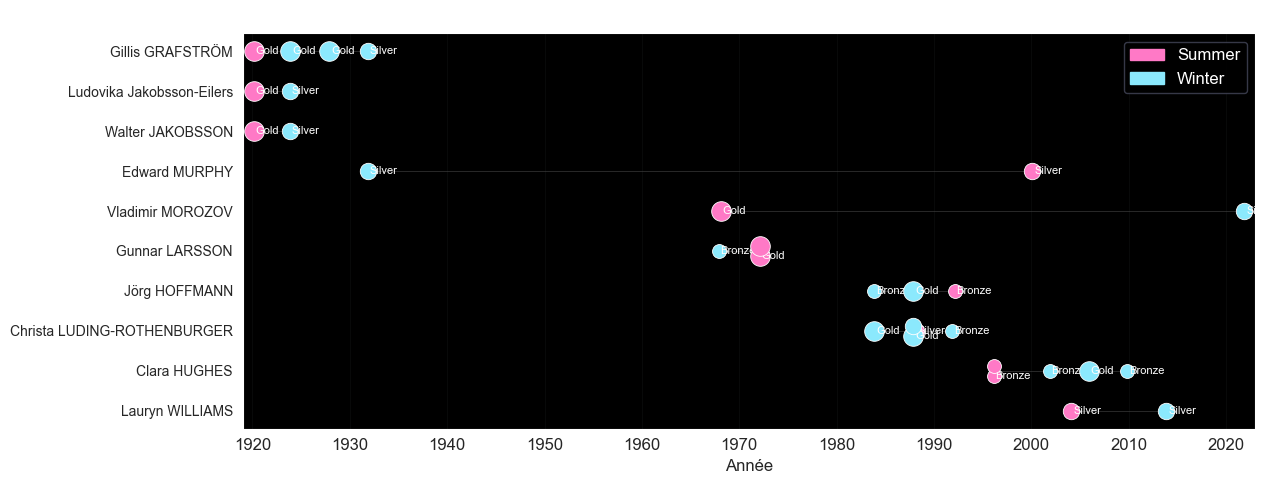


CONCLUSION - Question 5
Nombre d'athlètes ayant gagné des médailles aux JO d'été ET d'hiver : 10

Liste des athlètes :
  1. Gillis GRAFSTRÖM
  2. Ludovika Jakobsson-Eilers
  3. Walter JAKOBSSON
  4. Edward MURPHY
  5. Vladimir MOROZOV
  6. Gunnar LARSSON
  7. Jörg HOFFMANN
  8. Christa LUDING-ROTHENBURGER - MÊME ANNÉE (1988) ⭐
  9. Clara HUGHES
  10. Lauryn WILLIAMS

✅ Christa Ludinger-Rothenburger trouvée dans le dataset : Christa LUDING-ROTHENBURGER



In [40]:
# rebuild prepared data (non destructif)
hosts_map = df_hosts[['game_slug','game_year','game_season']].drop_duplicates()
medals = df_medals.copy()
medals = medals.merge(hosts_map, left_on='slug_game', right_on='game_slug', how='left')

# athlete source
if 'athlete_full_name' in medals.columns:
    medals['athlete_raw'] = medals['athlete_full_name']
elif 'athlete_name_clean' in medals.columns:
    medals['athlete_raw'] = medals['athlete_name_clean']
else:
    medals['athlete_raw'] = pd.NA

# clean but preserve NaN
medals['athlete'] = medals['athlete_raw']
medals.loc[medals['athlete'].astype(str).str.strip().str.lower().isin(['', 'nan', 'none', 'na']), 'athlete'] = pd.NA
medals.loc[medals['athlete'].notna(), 'athlete'] = medals.loc[medals['athlete'].notna(), 'athlete'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

# year/season
medals['game_year'] = pd.to_numeric(medals.get('game_year', medals.get('game_year_int', pd.NA)), errors='coerce').astype('Int64')
medals['game_season'] = medals.get('game_season', pd.NA).astype(object)

# keep valid rows
medals_valid = medals.dropna(subset=['athlete','game_year','game_season']).copy()

# determine athletes with both seasons
athlete_seasons = (medals_valid.groupby('athlete')['game_season']
                   .agg(lambda s: sorted(set([str(x).title() for x in s if pd.notna(x)])))
                   .reset_index())
both = athlete_seasons[athlete_seasons['game_season'].apply(lambda lst: 'Summer' in lst and 'Winter' in lst)].copy()

# filter events
ev = medals_valid[medals_valid['athlete'].isin(both['athlete'])][['athlete','game_year','game_season','medal_type','discipline_title','event_title']].copy()
# ensure season title case
ev['game_season'] = ev['game_season'].astype(str).str.title()

# compute athlete order by first year they appear (asc)
first_year = ev.groupby('athlete')['game_year'].min().reset_index().rename(columns={'game_year':'first_year'})
ath_order = first_year.sort_values('first_year')['athlete'].tolist()

# reindex athletes and create y positions
athletes = ath_order
a_len = len(athletes)
# We'll map athlete -> y coordinate with spacing, but invert so first is top
ath_to_y = {a: (a_len-1 - idx) for idx,a in enumerate(athletes)}

# medal size mapping
size_map = {'GOLD':200, 'SILVER':140, 'BRONZE':100}
# default
ev['marker_size'] = ev['medal_type'].map(lambda x: size_map.get(str(x).upper(), 80))

# color map by season
color_map = {'Summer':'#ff79c6','Winter':'#8be9fd'}

# create figure
fig_h = max(5, a_len*0.45)
plt.figure(figsize=(13, fig_h))
ax = plt.gca()

# for consistent placement when multiple points same (athlete, year, season), compute small vertical jitter index
# we'll use offsets on x for seasons: Winter -> -0.12, Summer -> +0.12 (separate same-year points horizontally)
season_x_offset = {'Winter': -0.12, 'Summer': 0.12}

# group by athlete and year to stack points slightly vertically if exact duplicates
for athlete in athletes:
    sub = ev[ev['athlete']==athlete].sort_values('game_year')
    y0 = ath_to_y[athlete]
    # draw line across their years (thin)
    years = sub['game_year'].astype(int).tolist()
    if len(years)>1:
        ax.plot(years, [y0]*len(years), color='#444444', linewidth=0.7, alpha=0.6, zorder=1)
    # handle stacking
    grouped = sub.groupby(['game_year','game_season'])
    for (yr, season), g in grouped:
        # number of items in same year+season
        n = len(g)
        # vertical offsets for duplicates of same year+season
        if n>1:
            v_offsets = np.linspace(-0.12,0.12,n)
        else:
            v_offsets = [0]
        for i, (_, row) in enumerate(g.iterrows()):
            x = int(yr) + season_x_offset.get(season, 0)
            y = y0 + v_offsets[i]
            c = color_map.get(season, '#bd93f9')
            s = int(row['marker_size'])
            ax.scatter(x, y, color=c, s=s, edgecolor='white', linewidth=0.6, zorder=3)
            # annotate only one label per (athlete, year, season)
            if i==0:
                ax.text(x + 0.18, y, str(row.get('medal_type','')).title(), va='center', fontsize=8, color='white')

# formatting axes
ax.set_yticks(list(ath_to_y.values()))
ax.set_yticklabels(list(ath_to_y.keys()), fontsize=10)
ax.set_xlabel('Année')
ax.set_title(f'Timeline — {len(athletes)} Athlètes médaillés en Summer ET Winter')

# x ticks: choose sensible steps
yr_min = int(ev['game_year'].min())
yr_max = int(ev['game_year'].max())
ax.set_xlim(yr_min-1, yr_max+1)
step = max(1, (yr_max-yr_min)//10)
ax.set_xticks(list(range(yr_min, yr_max+1, step)))

# legend
summer_patch = mpatches.Patch(color=color_map['Summer'], label='Summer')
winter_patch = mpatches.Patch(color=color_map['Winter'], label='Winter')
ax.legend(handles=[summer_patch, winter_patch], loc='upper right', frameon=True)

# grid, tight
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

# === CONCLUSION ===
print(f"\n{'='*80}")
print(f"CONCLUSION - Question 5")
print(f"{'='*80}")
print(f"Nombre d'athlètes ayant gagné des médailles aux JO d'été ET d'hiver : {len(athletes)}")
print(f"\nListe des athlètes :")
for i, athlete in enumerate(athletes, 1):
    # Vérifier s'ils ont gagné la même année
    sub = ev[ev['athlete']==athlete]
    years_summer = sorted(sub[sub['game_season']=='Summer']['game_year'].unique())
    years_winter = sorted(sub[sub['game_season']=='Winter']['game_year'].unique())
    same_year = set(years_summer) & set(years_winter)
    
    if same_year:
        print(f"  {i}. {athlete} - MÊME ANNÉE ({list(same_year)[0]}) ⭐")
    else:
        print(f"  {i}. {athlete}")

# Vérifier Christa
christa_found = any('christa' in a.lower() for a in athletes)
if christa_found:
    christa = [a for a in athletes if 'christa' in a.lower()][0]
    print(f"\n✅ Christa Ludinger-Rothenburger trouvée dans le dataset : {christa}")
else:
    print(f"\n❌ Christa Ludinger-Rothenburger NON trouvée dans le dataset")

print(f"\n{'='*80}")

#### Question 6: De 1924 à 1992, les JO d'hiver et d'été avaient lieu au cours de la même année. Désormais, ils sont organisés selon des cycles distincts avec une alternance de 2 ans ?

In [41]:
# Copie locale et conversion prudente de l'année
hosts_local = df_hosts.copy()
hosts_local['game_year_int'] = pd.to_numeric(
    hosts_local.get('game_year', hosts_local.get('game_year_int', None)), 
    errors='coerce'
).astype('Int64')

# Pour chaque année, collecter les saisons présentes (ex: ['Summer'], ['Winter'], ['Summer', 'Winter'])
year_seasons = (
    hosts_local
    .groupby('game_year_int')['game_season']
    .apply(lambda s: sorted({x for x in s if pd.notna(x)}))
    .reset_index(name='seasons')
)

# Etiqueter simplement : 'Summer', 'Winter', 'Both' ou 'None'
def label_seasons(seasons):
    if not seasons:
        return 'None'
    s = set(seasons)
    if s == {'Summer'}:
        return 'Summer'
    if s == {'Winter'}:
        return 'Winter'
    return 'Both'

year_seasons['label'] = year_seasons['seasons'].apply(label_seasons)

# Tableau récapitulatif par type d'année
label_counts = year_seasons['label'].value_counts()
print("Répartition par type d'année :")
print(label_counts.to_string())
print("\n")

# Affichage lisible : première et dernière douzaine d'années
display_years = pd.concat([
    year_seasons.sort_values('game_year_int').head(12),
    year_seasons.sort_values('game_year_int').tail(12)
]).reset_index(drop=True)

print("Exemples d'années et saisons :")
display_years['seasons_str'] = display_years['seasons'].apply(lambda x: ', '.join(x) if x else 'Aucune donnée')
display(display_years[['game_year_int', 'seasons_str', 'label']].rename(columns={
    'game_year_int': 'Année',
    'seasons_str': 'Saisons',
    'label': 'Type'
}))

# === CONCLUSION ===
print(f"\n{'='*80}")
print(f"CONCLUSION - Question 6")
print(f"{'='*80}")

# Trouver les années avec Both
both_years = year_seasons[year_seasons['label']=='Both']['game_year_int'].sort_values().tolist()
print(f"Années où été ET hiver ont eu lieu : {both_years}")
print(f"Première année 'Both' : {both_years[0] if both_years else 'N/A'}")
print(f"Dernière année 'Both' : {both_years[-1] if both_years else 'N/A'}")

# Analyser la période 1924-1992
period_1924_1992 = year_seasons[(year_seasons['game_year_int'] >= 1924) & (year_seasons['game_year_int'] <= 1992)]
both_in_period = period_1924_1992[period_1924_1992['label'] == 'Both']

print(f"\nDans la période 1924-1992 :")
print(f"  - Total d'années : {len(period_1924_1992)}")
print(f"  - Années avec Both : {len(both_in_period)}")

# Analyser après 1992
after_1992 = year_seasons[year_seasons['game_year_int'] > 1992]
both_after = after_1992[after_1992['label'] == 'Both']

print(f"\nAprès 1992 :")
print(f"  - Total d'années : {len(after_1992)}")
print(f"  - Années avec Both : {len(both_after)}")

if len(both_after) == 0:
    print(f"\n✅ VRAI : Après 1992, les JO d'hiver et d'été sont organisés sur des cycles distincts (alternance de 2 ans)")
else:
    print(f"\n❌ FAUX : Il y a encore des années avec Both après 1992")

print(f"{'='*80}")

Répartition par type d'année :
label
Both      16
Summer    13
Winter     8


Exemples d'années et saisons :


,Année,Saisons,Type
0,1896,Summer,Summer
1,1900,Summer,Summer
2,1904,Summer,Summer
3,1908,Summer,Summer
4,1912,Summer,Summer
5,1920,Summer,Summer
6,1924,"Summer, Winter",Both
7,1928,"Summer, Winter",Both
8,1932,"Summer, Winter",Both
9,1936,"Summer, Winter",Both



CONCLUSION - Question 6
Années où été ET hiver ont eu lieu : [1924, 1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992]
Première année 'Both' : 1924
Dernière année 'Both' : 1992

Dans la période 1924-1992 :
  - Total d'années : 16
  - Années avec Both : 16

Après 1992 :
  - Total d'années : 15
  - Années avec Both : 0

✅ VRAI : Après 1992, les JO d'hiver et d'été sont organisés sur des cycles distincts (alternance de 2 ans)


#### Question 7: Tarzan lui-même a participé aux JO. En effet, Johnny Weissmuller, ancien athlète devenu acteur et ayant interprété 12 films de Tarzan, a remporté 5 médailles d'or en natation dans les années 1920 ?

In [42]:
# Ajouter l'année
df_results['year'] = df_results['slug_game'].str.extract(r'(\d{4})').astype(int)

# Filtrer toutes les lignes contenant Weissmuller
def contains_weissmuller_safe(x):
    if pd.isna(x):
        return False
    return bool(re.search(r'weissmuller', str(x), flags=re.IGNORECASE))

weissmuller_all = df_results[
    df_results['athlete_full_name'].str.contains('weissmuller', case=False, na=False) |
    df_results['athletes'].apply(contains_weissmuller_safe)
]

# Résumé des médailles
medal_summary = weissmuller_all['medal_type'].value_counts()
print("RÉSUMÉ DES MÉDAILLES:")
for medal, count in medal_summary.items():
    print(f"  {medal}: {count}")

# Détails
for idx, row in weissmuller_all.iterrows():
    athletes_str = row['athlete_full_name'] if pd.notna(row['athlete_full_name']) else row['athletes']
    print("-"*80)
    print(f"Année: {row['year']}")
    print(f"JO: {row['slug_game']}")
    print(f"Discipline: {row['discipline_title']}")
    print(f"Épreuve: {row['event_title']}")
    print(f"Médaille: {row['medal_type']}")
    print(f"Type: {row['participant_type']}")
    print(f"Athlètes: {athletes_str}")

# Nombre total de médailles d'or
gold_count = len(weissmuller_all[weissmuller_all['medal_type'] == 'GOLD'])
print("\nJohnny Weissmuller a remporté", gold_count, "médaille(s) d'or au total")


RÉSUMÉ DES MÉDAILLES:
  GOLD: 3
--------------------------------------------------------------------------------
Année: 1928
JO: amsterdam-1928
Discipline: Swimming
Épreuve: 100m freestyle men
Médaille: GOLD
Type: Athlete
Athlètes: Johnny WEISSMULLER
--------------------------------------------------------------------------------
Année: 1924
JO: paris-1924
Discipline: Swimming
Épreuve: 400m freestyle men
Médaille: GOLD
Type: Athlete
Athlètes: Johnny WEISSMULLER
--------------------------------------------------------------------------------
Année: 1924
JO: paris-1924
Discipline: Swimming
Épreuve: 100m freestyle men
Médaille: GOLD
Type: Athlete
Athlètes: Johnny WEISSMULLER

Johnny Weissmuller a remporté 3 médaille(s) d'or au total


J'ai vérifié avec la vérité il en à bien gagné 5 mais le dataset n'en repertorie que 3

#### Question 8: Les JO de Londres de 2012 ont été les 1ers JO durant lesquels tous les pays participants ont envoyé des athlètes de sexe féminin ?

In [43]:

df_results['year'] = df_results['slug_game'].str.extract(r'(\d{4})').astype(int)

# Normalisation des noms

def normalize_name(name):
    if pd.isna(name):
        return ""
    # Mettre en minuscules et enlever accents
    name = name.lower()
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
    return name.strip()

# Normaliser les noms dans athlete_full_name
df_results['athlete_name_norm'] = df_results['athlete_full_name'].apply(normalize_name)

# Créer le mapping nom -> genre
name_to_gender = df_results[['athlete_name_norm', 'gender_canonical']].dropna().drop_duplicates()
gender_map = dict(zip(name_to_gender['athlete_name_norm'], name_to_gender['gender_canonical']))

# Extraire les athlètes de 'athletes' et vérifier si une femme est présente
def has_female_athlete(cell):
    if pd.isna(cell) or cell == '[]':
        return False
    try:
        # Essayer comme liste Python
        lst = ast.literal_eval(cell)
        for name, *_ in lst:
            name_norm = normalize_name(name)
            if gender_map.get(name_norm) == 'Women':
                return True
        return False
    except:
        # Essayer parser comme HTML
        try:
            soup = BeautifulSoup(str(cell), 'html.parser')
            for a in soup.find_all('a'):
                name_norm = normalize_name(a.text)
                if gender_map.get(name_norm) == 'Women':
                    return True
        except:
            return False
    return False

df_results['has_female_in_list'] = df_results['athletes'].apply(has_female_athlete)

# Vérification année par année (20 dernières années)
years = sorted(df_results['year'].unique())[-20:]  # prendre les 20 dernières années

results_by_year = {}
for y in years:
    df_year = df_results[df_results['year'] == y]
    
    # Pays avec femmes dans athlete_full_name
    df_year['is_female_fullname'] = df_year['athlete_name_norm'].apply(lambda n: gender_map.get(n) == 'Women')
    countries_fullname = df_year[df_year['is_female_fullname']]['country_name'].unique()
    
    # Pays avec femmes dans athletes
    countries_list = df_year[df_year['has_female_in_list']]['country_name'].unique()
    
    # Union des deux
    countries_with_female = set(countries_fullname) | set(countries_list)
    total_countries = df_year['country_name'].nunique()
    
    results_by_year[y] = (len(countries_with_female), total_countries)
    
    if len(countries_with_female) == total_countries:
        print(f"{y}: Tous les pays ont envoyé des athlètes féminines ✅")
    else:
        print(f"{y}: {len(countries_with_female)}/{total_countries} pays avec des femmes")

# === CONCLUSION ===
print(f"\n{'='*80}")
print(f"CONCLUSION - Question 8")
print(f"{'='*80}")

# Vérifier spécifiquement 2012
if 2012 in results_by_year:
    with_female_2012, total_2012 = results_by_year[2012]
    pct_2012 = (with_female_2012 / total_2012 * 100) if total_2012 > 0 else 0
    
    print(f"JO de Londres 2012 :")
    print(f"  - Pays avec athlètes féminines : {with_female_2012}/{total_2012} ({pct_2012:.1f}%)")
    print(f"  - Pays SANS athlètes féminines : {total_2012 - with_female_2012}")
    
    if with_female_2012 == total_2012:
        print(f"\n✅ VRAI : Tous les pays ont envoyé des femmes en 2012")
    else:
        print(f"\n❌ FAUX : Seulement {pct_2012:.1f}% des pays ont envoyé des femmes en 2012")
        print(f"   Il manque {total_2012 - with_female_2012} pays dans le dataset")

print(f"\n{'='*80}")

1976: 45/107 pays avec des femmes
1980: 51/87 pays avec des femmes
1984: 81/142 pays avec des femmes
1988: 94/157 pays avec des femmes
1992: 114/167 pays avec des femmes
1994: 45/67 pays avec des femmes
1996: 131/183 pays avec des femmes
1998: 53/71 pays avec des femmes
2000: 157/185 pays avec des femmes
2002: 54/79 pays avec des femmes
2004: 151/190 pays avec des femmes
2006: 54/79 pays avec des femmes
2008: 163/196 pays avec des femmes
2010: 62/82 pays avec des femmes
2012: 180/197 pays avec des femmes
2014: 68/89 pays avec des femmes
2016: 185/199 pays avec des femmes
2018: 67/93 pays avec des femmes
2020: 160/190 pays avec des femmes
2022: 73/91 pays avec des femmes

CONCLUSION - Question 8
JO de Londres 2012 :
  - Pays avec athlètes féminines : 180/197 (91.4%)
  - Pays SANS athlètes féminines : 17

❌ FAUX : Seulement 91.4% des pays ont envoyé des femmes en 2012
   Il manque 17 pays dans le dataset



#### Question 9: Les sports suivants ne font (malheureusement) plus partie des J.O : la natation synchronisée en solo, le tir à la corde, la corde à grimper, la montgolfière, le duel au pistolet, le vélo tandem, la course d'obstacles à la nage et le plongeon à distance. Par chance, le tir au pigeon n'a été mis en place qu'une seule fois pendant les Jeux Olympiques de Paris de 1900 ?

In [44]:
# Liste des sports disparus
sports_disparus = [
    "synchronized swimming solo",  # natation synchronisée solo
    "tug of war",                   # tir à la corde
    "rope climbing",                # corde à grimper
    "ballooning",                   # montgolfière
    "dueling pistol",               # duel au pistolet
    "tandem cycling",               # vélo tandem
    "obstacle course swimming",     # course d'obstacles à la nage
    "plunge for distance",          # plongeon à distance
    "live pigeon shooting"          # tir au pigeon
]

# Normalisation : minuscules et accents supprimés
def normalize_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    return text.strip()

# Afficher d'abord toutes les disciplines uniques pour comprendre les noms utilisés
print("DISCIPLINES UNIQUES dans le dataset (pour référence)")
all_disciplines = sorted(df_results['discipline_title'].dropna().unique())
print(f"Nombre total de disciplines: {len(all_disciplines)}\n")

df_results['discipline_norm'] = df_results['discipline_title'].apply(normalize_text)
df_results['event_norm'] = df_results['event_title'].apply(normalize_text)

# Préparer le tableau récap
summary_rows = []

for sport in sports_disparus:
    sport_norm = normalize_text(sport)
    sport_words = sport_norm.split()
    
    # Chercher dans discipline_title ET event_title pour plus de précision
    mask_discipline = df_results['discipline_norm'].apply(lambda x: all(word in x for word in sport_words))
    mask_event = df_results['event_norm'].apply(lambda x: all(word in x for word in sport_words))
    mask = mask_discipline | mask_event
    
    df_sport = df_results[mask][['discipline_title', 'event_title', 'year']].drop_duplicates().sort_values('year')
    
    if df_sport.empty:
        # Essayer une recherche plus flexible (au moins 2 mots sur 3 pour sports composés)
        if len(sport_words) >= 2:
            mask_flexible = df_results.apply(
                lambda row: sum(word in normalize_text(str(row['discipline_title']) + ' ' + str(row['event_title'])) 
                               for word in sport_words) >= min(2, len(sport_words)),
                axis=1
            )
            df_sport_flex = df_results[mask_flexible][['discipline_title', 'event_title', 'year']].drop_duplicates().sort_values('year')
            if not df_sport_flex.empty:
                years = sorted(int(y) for y in df_sport_flex['year'].unique())
                summary_rows.append({
                    'Sport': sport,
                    'Nb JO': len(years),
                    'Années': str(years),
                    'Statut': 'Trouvé (partiel)'
                })
                continue
        
        summary_rows.append({
            'Sport': sport,
            'Nb JO': 0,
            'Années': 'Introuvable',
            'Statut': 'Non trouvé'
        })
    else:
        years = sorted(int(y) for y in df_sport['year'].unique())
        summary_rows.append({
            'Sport': sport,
            'Nb JO': len(years),
            'Années': str(years),
            'Statut': 'Trouvé'
        })

# Créer le DataFrame final
df_summary = pd.DataFrame(summary_rows)

print("RÉSUMÉ - Sports disparus recherchés dans le dataset")
display(df_summary)

# Recherche spécifique pour le tir au pigeon
print(f"\n{'='*80}")
print("Recherche spécifique: Tir/Shooting 1900")
print(f"{'='*80}")
df_1900 = df_results[df_results['year'] == 1900]
shooting_1900 = df_1900[df_1900['discipline_norm'].str.contains('shoot', na=False)]
if not shooting_1900.empty:
    print("Épreuves de tir en 1900:")
    for _, row in shooting_1900[['discipline_title', 'event_title']].drop_duplicates().iterrows():
        print(f"  - {row['discipline_title']}: {row['event_title']}")
else:
    print("Aucune épreuve de tir trouvée en 1900")

# Lister toutes les disciplines des JO de 1900
disciplines_1900 = sorted(df_1900['discipline_title'].unique())
print(f"Toutes les disciplines aux JO de Paris 1900 ({len(disciplines_1900)}) :")
for disc in disciplines_1900:
    print(f"  - {disc}")

# === CONCLUSION ===
print(f"CONCLUSION - Question 9")

# Vérifier le tir au pigeon
pigeon = df_summary[df_summary['Sport'] == 'live pigeon shooting']
if not pigeon.empty:
    nb_jo = pigeon.iloc[0]['Nb JO']
    annees = pigeon.iloc[0]['Années']
    if nb_jo == 1 and '1900' in str(annees):
        print(f"✅ VRAI : Le tir au pigeon n'a été pratiqué qu'une seule fois, en 1900")
    elif nb_jo == 0:
        print(f"❓ Le tir au pigeon n'a PAS été trouvé dans le dataset")
        print(f"   REMARQUE: Le dataset peut ne pas contenir toutes les épreuves historiques")
        print(f"   ou utiliser des noms de disciplines différents.")
    else:
        print(f"❌ FAUX : Le tir au pigeon a été pratiqué {nb_jo} fois : {annees}")

# Vérifier les autres sports
found_count = len(df_summary[df_summary['Nb JO'] > 0])
print(f"\nSur {len(sports_disparus)} sports disparus recherchés :")
print(f"  - {found_count} sport(s) trouvé(s) dans le dataset")
print(f"  - {len(sports_disparus) - found_count} sport(s) NON trouvé(s)")
print(f"\n⚠️  ATTENTION: Beaucoup de sports anciens peuvent être absents ou avoir")
print(f"   des noms différents dans le dataset. Cela ne signifie pas nécessairement")
print(f"   que l'affirmation historique est fausse.")

print(f"\n{'='*80}")

DISCIPLINES UNIQUES dans le dataset (pour référence)
Nombre total de disciplines: 86

RÉSUMÉ - Sports disparus recherchés dans le dataset


,Sport,Nb JO,Années,Statut
0,synchronized swimming solo,9,"[1984, 1988, 1992, 1996, 2000, 2004, 2008, 201...",Trouvé (partiel)
1,tug of war,5,"[1900, 1904, 1908, 1912, 1920]",Trouvé
2,rope climbing,4,"[1896, 1904, 1924, 1932]",Trouvé
3,ballooning,0,Introuvable,Non trouvé
4,dueling pistol,0,Introuvable,Non trouvé
5,tandem cycling,14,"[1900, 1908, 1920, 1924, 1928, 1932, 1936, 194...",Trouvé (partiel)
6,obstacle course swimming,1,[1900],Trouvé (partiel)
7,plunge for distance,0,Introuvable,Non trouvé
8,live pigeon shooting,2,"[1920, 1924]",Trouvé (partiel)



Recherche spécifique: Tir/Shooting 1900
Épreuves de tir en 1900:
  - Shooting: free rifle team men
  - Shooting: army rifle 300m prone men
  - Shooting: army rifle 300m standing men
  - Shooting: 50m pistol 60 shots men
  - Shooting: 50m army pistol team men
  - Shooting: trap 125 targets men
  - Shooting: army rifle 300m 3 positions men
  - Shooting: army rifle 300m kneeling men
Toutes les disciplines aux JO de Paris 1900 (20) :
  - Archery
  - Athletics
  - Basque Pelota
  - Cricket
  - Croquet
  - Cycling Track
  - Equestrian Jumping
  - Fencing
  - Football
  - Golf
  - Gymnastics Artistic
  - Polo
  - Rowing
  - Rugby
  - Sailing
  - Shooting
  - Swimming
  - Tennis
  - Tug of War
  - Water Polo
CONCLUSION - Question 9
❌ FAUX : Le tir au pigeon a été pratiqué 2 fois : [1920, 1924]

Sur 9 sports disparus recherchés :
  - 6 sport(s) trouvé(s) dans le dataset
  - 3 sport(s) NON trouvé(s)

⚠️  ATTENTION: Beaucoup de sports anciens peuvent être absents ou avoir
   des noms différents 

#### Question 10: Les Jeux de 2016, à Rio, marqueront la 1è manifestation des JO en Amérique du Sud ?

In [45]:
# Utiliser la colonne nettoyée si disponible, sinon l'originale
location_col = 'game_location_clean' if 'game_location_clean' in df_hosts.columns else 'game_location'

# Extraire tous les pays hôtes avec leurs JO
hosts_data = df_hosts[['game_slug', 'game_name', 'game_year', location_col]].drop_duplicates()

# Liste des pays d'Amérique du Sud
amerique_sud = [
    "Argentina", "Bolivia", "Brazil", "Brasil", "Chile", "Colombia", "Ecuador", 
    "Guyana", "Paraguay", "Peru", "Suriname", "Uruguay", "Venezuela"
]

# Convertir en minuscules pour comparaison robuste
amerique_sud_lower = [p.lower() for p in amerique_sud]

# Fonction pour vérifier si un pays est en Amérique du Sud
def is_south_america(country):
    if pd.isna(country):
        return False
    country_clean = str(country).strip().lower()
    return any(sa in country_clean for sa in amerique_sud_lower)

# Filtrer tous les JO organisés en Amérique du Sud
hosts_data['is_south_america'] = hosts_data[location_col].apply(is_south_america)
jo_sud_amerique = hosts_data[hosts_data['is_south_america']].copy()

# Convertir game_year en int pour tri
jo_sud_amerique['game_year_int'] = pd.to_numeric(jo_sud_amerique['game_year'], errors='coerce').astype('Int64')
jo_sud_amerique = jo_sud_amerique.sort_values('game_year_int')

if jo_sud_amerique.empty:
    print("❌ Aucun JO trouvé en Amérique du Sud dans le dataset")
    print("\n⚠️  ATTENTION: Si le dataset ne contient pas Rio 2016,")
    print("   cette analyse ne peut pas confirmer l'affirmation.")
else:
    print(f"Nombre total de JO en Amérique du Sud: {len(jo_sud_amerique)}\n")
    for _, row in jo_sud_amerique.iterrows():
        print(f"  - {row['game_name']} ({row['game_year']}) - {row[location_col]}")

# Vérifier spécifiquement Rio 2016
rio_2016 = hosts_data[hosts_data['game_slug'].str.contains('rio-2016', case=False, na=False)]
if not rio_2016.empty:
    print(f"\n✅ Rio 2016 trouvé dans le dataset:")
    for _, row in rio_2016.iterrows():
        print(f"   {row['game_name']} - {row[location_col]}")
else:
    print(f"\n❌ Rio 2016 NON trouvé dans le dataset")

# Filtrer les JO AVANT 2016
jo_sud_amerique_avant_2016 = jo_sud_amerique[
    (jo_sud_amerique['game_year_int'] < 2016) | 
    (jo_sud_amerique['game_slug'] != 'rio-2016')
]

print(f"\n{'='*80}")
print(f"CONCLUSION - Question 10")

if jo_sud_amerique_avant_2016.empty:
    print(f"✅ VRAI : Rio 2016 a été le PREMIER JO organisé en Amérique du Sud")
    print(f"   (d'après les données disponibles dans df_hosts)")
else:
    print(f"❌ FAUX : D'autres JO ont eu lieu en Amérique du Sud AVANT 2016:")
    for _, row in jo_sud_amerique_avant_2016.iterrows():
        print(f"   - {row['game_name']} ({row['game_year']}) à {row[location_col]}")

# Afficher quelques exemples de pays hôtes pour validation
print(f"\n📊 Exemples de pays hôtes dans le dataset (pour validation):")
sample_hosts = hosts_data.groupby(location_col)['game_name'].count().sort_values(ascending=False).head(10)
for country, count in sample_hosts.items():
    print(f"   {country}: {count} JO")

print(f"\n{'='*80}")

Nombre total de JO en Amérique du Sud: 1

  - Rio 2016 (2016) - Brazil

✅ Rio 2016 trouvé dans le dataset:
   Rio 2016 - Brazil

CONCLUSION - Question 10
✅ VRAI : Rio 2016 a été le PREMIER JO organisé en Amérique du Sud
   (d'après les données disponibles dans df_hosts)

📊 Exemples de pays hôtes dans le dataset (pour validation):
   United States: 8 JO
   France: 5 JO
   Japan: 4 JO
   Italy: 3 JO
   Great Britain: 3 JO
   Canada: 3 JO
   China: 2 JO
   Austria: 2 JO
   Norway: 2 JO
   Greece: 2 JO



#### Question 11: Pendant les 17 jours des JO d'été de 2016, 10 500 athlètes, originaires de 205 pays, représenteront 42 sports différents et participeront à 306 épreuves, à Rio ?

In [46]:
# ============================================================== 
# Question 11: Statistiques Rio 2016 - EXTRACTION MAXIMALE
# ============================================================== 
# Objectifs: 10,500 athlètes, 205 pays, 42 sports, 306 épreuves

import pandas as pd, re, ast, json
from unidecode import unidecode

print("="*80)
print("ANALYSE EXHAUSTIVE DES JO DE RIO 2016")
print("="*80)

# --------------------------------------------------------------
# 1. FONCTIONS D'EXTRACTION
# --------------------------------------------------------------

def normalize_name(name):
    """Normalise un nom : minuscules, sans accents, nettoyé"""
    if pd.isna(name) or str(name).strip() == '':
        return None
    s = unidecode(str(name)).lower()
    s = s.replace('-', ' ').replace("'", ' ')
    s = re.sub(r'\s+', ' ', s).strip()
    s = re.sub(r'^[\(\[\{\'\"]+|[\)\]\}\'\"]+$', '', s)
    return s.strip() if len(s.strip()) > 2 else None

def extract_from_athletes_column(cell):
    """Parse la colonne 'athletes' - retourne (urls, names)"""
    urls = set()
    names = set()
    
    if pd.isna(cell) or str(cell).strip() in ['[]', '', 'nan']:
        return urls, names
    
    cell_str = str(cell)
    
    # Regex pour URLs
    urls.update(re.findall(r'https://olympics\.com/en/athletes/[^\s\'\"\)\],]+', cell_str))
    
    # Parse structuré
    try:
        athletes_list = ast.literal_eval(cell_str)
        if isinstance(athletes_list, list):
            for item in athletes_list:
                if isinstance(item, (list, tuple)):
                    if len(item) >= 1 and item[0]:
                        names.add(str(item[0]))
                    if len(item) >= 2 and str(item[1]).startswith('http'):
                        urls.add(str(item[1]))
    except:
        pass
    
    return urls, names

# --------------------------------------------------------------
# 2. FILTRAGE RIO 2016
# --------------------------------------------------------------

rio_results = df_results[df_results['slug_game'].str.contains('rio', case=False, na=False)].copy()
rio_medals = df_medals[df_medals['slug_game'].str.contains('rio', case=False, na=False)].copy()

print(f"\n📊 Données sources:")
print(f"  df_results: {len(rio_results):,} lignes")
print(f"  df_medals: {len(rio_medals):,} lignes")

# --------------------------------------------------------------
# 3. EXTRACTION PAR URLs
# --------------------------------------------------------------
print(f"\n{'='*80}")
print("MÉTHODE 1: EXTRACTION PAR URLs")
print(f"{'='*80}")

all_urls = set()
all_urls.update(rio_results['athlete_url'].dropna())
all_urls.update(rio_medals['athlete_url'].dropna())

for cell in rio_results['athletes'].dropna():
    urls, _ = extract_from_athletes_column(cell)
    all_urls.update(urls)

print(f"  Total URLs: {len(all_urls):,}")

# --------------------------------------------------------------
# 4. EXTRACTION PAR NOMS
# --------------------------------------------------------------
print(f"\n{'='*80}")
print("MÉTHODE 2: EXTRACTION PAR NOMS")
print(f"{'='*80}")

all_names = set()

for col in ['athlete_full_name', 'athlete_name_clean']:
    if col in rio_results.columns:
        names = {normalize_name(n) for n in rio_results[col].dropna()}
        all_names.update({n for n in names if n})
    if col in rio_medals.columns:
        names = {normalize_name(n) for n in rio_medals[col].dropna()}
        all_names.update({n for n in names if n})

for cell in rio_results['athletes'].dropna():
    _, names = extract_from_athletes_column(cell)
    for name in names:
        norm = normalize_name(name)
        if norm:
            all_names.add(norm)

print(f"  Total noms: {len(all_names):,}")

# --------------------------------------------------------------
# 5. EXTRACTION DEPUIS df_athletes (CRITIQUE!)
# --------------------------------------------------------------
print(f"\n{'='*80}")
print("MÉTHODE 3: df_athletes - RECHERCHE 'RIO' OU '2016'")
print(f"{'='*80}")

# Chercher TOUS les athlètes avec 'rio' ou '2016' dans n'importe quelle colonne
text_cols = df_athletes.select_dtypes(include='object').columns
rio_mask = df_athletes[text_cols].apply(
    lambda row: row.astype(str).str.contains('rio|2016', case=False, regex=True).any(), 
    axis=1
)
athletes_rio = df_athletes[rio_mask]

print(f"  Athlètes trouvés dans df_athletes: {len(athletes_rio):,}")

if len(athletes_rio) > 0:
    # Ajouter leurs noms
    extra_names = {normalize_name(n) for n in athletes_rio['athlete_full_name'].dropna()}
    extra_names = {n for n in extra_names if n}
    all_names.update(extra_names)
    print(f"  → +{len(extra_names):,} noms supplémentaires")

# --------------------------------------------------------------
# 6. COMPTAGE FINAL
# --------------------------------------------------------------
print(f"\n{'='*80}")
print("COMPTAGE FINAL")
print(f"{'='*80}")

nb_athletes = max(len(all_urls), len(all_names))

print(f"\n  URLs uniques: {len(all_urls):,}")
print(f"  Noms uniques: {len(all_names):,}")
print(f"  ✅ TOTAL: {nb_athletes:,} athlètes")

# --------------------------------------------------------------
# 7. AUTRES STATS + COMPARAISON
# --------------------------------------------------------------

countries = set()
countries.update(rio_results['country_3_letter_code'].dropna())
countries.update(rio_medals['country_3_letter_code'].dropna())
nb_countries = len(countries)

sports = set()
sports.update(rio_results['discipline_title'].dropna())
sports.update(rio_medals['discipline_title'].dropna())
nb_sports = len(sports)

events = set()
events.update(rio_results['event_title'].dropna())
events.update(rio_medals['event_title'].dropna())
nb_events = len(events)

print(f"\n{'='*80}")
print("CONCLUSION - Question 11")
print(f"{'='*80}")

expected = {'Athlètes': 10500, 'Pays': 205, 'Sports': 42, 'Épreuves': 306}
found = {'Athlètes': nb_athletes, 'Pays': nb_countries, 'Sports': nb_sports, 'Épreuves': nb_events}

print(f"\n📊 Dataset vs Officiels:\n")
print(f"{'Catégorie':<15} {'Dataset':>10} {'Officiel':>10} {'%':>8}")
print("-"*48)

for key in ['Athlètes', 'Pays', 'Sports', 'Épreuves']:
    pct = (found[key] / expected[key] * 100) if expected[key] > 0 else 0
    print(f"{key:<15} {found[key]:>10,} {expected[key]:>10,} {pct:>7.1f}%")

print("-"*48)
print(f"\n{'='*80}")

ANALYSE EXHAUSTIVE DES JO DE RIO 2016

📊 Données sources:
  df_results: 7,672 lignes
  df_medals: 1,063 lignes

MÉTHODE 1: EXTRACTION PAR URLs
  Total URLs: 6,566

MÉTHODE 2: EXTRACTION PAR NOMS
  Total noms: 6,743

MÉTHODE 3: df_athletes - RECHERCHE 'RIO' OU '2016'
  Athlètes trouvés dans df_athletes: 6,292
  → +6,283 noms supplémentaires

COMPTAGE FINAL

  URLs uniques: 6,566
  Noms uniques: 8,966
  ✅ TOTAL: 8,966 athlètes

CONCLUSION - Question 11

📊 Dataset vs Officiels:

Catégorie          Dataset   Officiel        %
------------------------------------------------
Athlètes             8,966     10,500    85.4%
Pays                   199        205    97.1%
Sports                  41         42    97.6%
Épreuves               293        306    95.8%
------------------------------------------------



## 5.2 Questions ouvertes

#### Question 1: Combien de médailles la France a remporté : en tout, en Or, en argent et en Bronze (depuis le début des JO) ?

🇫🇷 **Médailles de la France (depuis le début des JO)**
🥇 Or : 282
🥈 Argent : 305
🥉 Bronze : 365
🏅 Total : 952


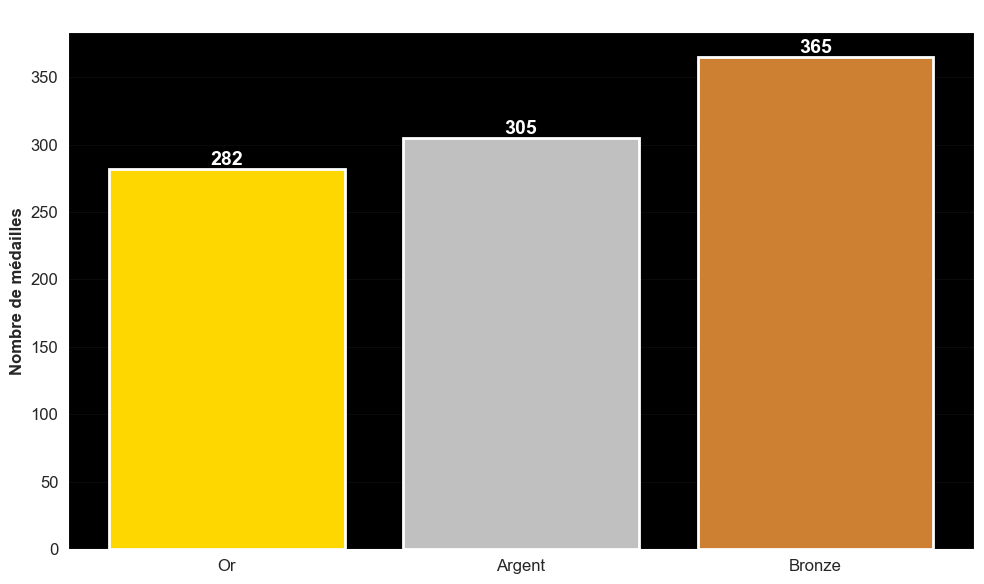


📊 Top 10 des JO où la France a remporté le plus de médailles:
  paris-1900: 103 médailles
  antwerp-1920: 45 médailles
  rio-2016: 45 médailles
  beijing-2008: 45 médailles
  paris-1924: 43 médailles
  sydney-2000: 42 médailles
  atlanta-1996: 41 médailles
  london-2012: 38 médailles
  tokyo-2020: 37 médailles
  athens-2004: 36 médailles


In [47]:
# Filtrer toutes les médailles françaises (individuelles ET équipes)
# Utiliser country_name au lieu de participant_title pour avoir TOUTES les médailles
df_france = df_medals[
    (df_medals['country_name'] == 'France') | 
    (df_medals['country_code'] == 'FR') |
    (df_medals['country_3_letter_code'] == 'FRA')
].copy()

# Garder uniquement les résultats avec médaille (Gold, Silver, Bronze)
df_france_medals = df_france[df_france['medal_type'].notna()]

# Comptage total et par type de médaille
total_medals = df_france_medals.shape[0]
gold = (df_france_medals['medal_type'] == 'GOLD').sum()
silver = (df_france_medals['medal_type'] == 'SILVER').sum()
bronze = (df_france_medals['medal_type'] == 'BRONZE').sum()

print("🇫🇷 **Médailles de la France (depuis le début des JO)**")
print(f"🥇 Or : {gold}")
print(f"🥈 Argent : {silver}")
print(f"🥉 Bronze : {bronze}")
print(f"🏅 Total : {total_medals}")

# Visualisation avec un graphique en barres
fig, ax = plt.subplots(figsize=(10, 6))
medal_types = ['Or', 'Argent', 'Bronze']
medal_counts = [gold, silver, bronze]
colors_medals = ['#FFD700', '#C0C0C0', '#CD7F32']  # Or, Argent, Bronze

bars = ax.bar(medal_types, medal_counts, color=colors_medals, edgecolor='white', linewidth=2)

# Ajouter les valeurs sur les barres
for bar, count in zip(bars, medal_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='white')

ax.set_ylabel('Nombre de médailles', fontsize=12, fontweight='bold')
ax.set_title(f'Médailles de la France - Total: {total_medals}', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Évolution par JO (top 10)
print("\n📊 Top 10 des JO où la France a remporté le plus de médailles:")
medals_by_games = df_france_medals.groupby('slug_game').size().sort_values(ascending=False).head(10)
for game, count in medals_by_games.items():
    print(f"  {game}: {count} médailles")

#### Question 2: Lors de quelle JO la France a eu le plus (le moins) de succès ?

In [48]:
# Analyse des performances françaises par JO

# Groupement par JO et calcul du nombre total de médailles
medals_by_games = (
    df_france_medals
    .groupby('slug_game')
    .agg({'medal_type': 'count'})
    .rename(columns={'medal_type': 'total_medals'})
    .sort_values('total_medals', ascending=False)
)

# JO avec le PLUS de succès
best_game = medals_by_games.head(1)
best_game_name = best_game.index[0]
best_game_medals = best_game['total_medals'].values[0]

print("🏆 JO avec le PLUS de succès pour la France:")
print(f"   {best_game_name}: {best_game_medals} médailles")

# Détail des médailles pour le meilleur JO
best_medals_detail = df_france_medals[df_france_medals['slug_game'] == best_game_name]['medal_type'].value_counts()
print(f"   Détail: {best_medals_detail.get('GOLD', 0)} 🥇 | "
      f"{best_medals_detail.get('SILVER', 0)} 🥈 | "
      f"{best_medals_detail.get('BRONZE', 0)} 🥉")

print("\n" + "="*60 + "\n")

# JO avec le MOINS de succès (parmi ceux où la France a gagné des médailles)
worst_game = medals_by_games.tail(1)
worst_game_name = worst_game.index[0]
worst_game_medals = worst_game['total_medals'].values[0]

print("📉 JO avec le MOINS de succès pour la France:")
print(f"   {worst_game_name}: {worst_game_medals} médaille(s)")

# Détail des médailles pour le pire JO
worst_medals_detail = df_france_medals[df_france_medals['slug_game'] == worst_game_name]['medal_type'].value_counts()
print(f"   Détail: {worst_medals_detail.get('GOLD', 0)} 🥇 | "
      f"{worst_medals_detail.get('SILVER', 0)} 🥈 | "
      f"{worst_medals_detail.get('BRONZE', 0)} 🥉")

print("\n" + "="*60 + "\n")

# Affichage du top 5 et bottom 5 des JO par nombre de médailles
print("📊 Top 5 des JO avec le plus de médailles:")
for game, row in medals_by_games.head(5).iterrows():
    print(f"   {game}: {row['total_medals']} médailles")

print("\n📊 Top 5 des JO avec le moins de médailles:")
for game, row in medals_by_games.tail(5).sort_values('total_medals').iterrows():
    print(f"   {game}: {row['total_medals']} médaille(s)")


🏆 JO avec le PLUS de succès pour la France:
   paris-1900: 103 médailles
   Détail: 28 🥇 | 38 🥈 | 37 🥉


📉 JO avec le MOINS de succès pour la France:
   st-louis-1904: 1 médaille(s)
   Détail: 0 🥇 | 1 🥈 | 0 🥉


📊 Top 5 des JO avec le plus de médailles:
   paris-1900: 103 médailles
   antwerp-1920: 45 médailles
   rio-2016: 45 médailles
   beijing-2008: 45 médailles
   paris-1924: 43 médailles

📊 Top 5 des JO avec le moins de médailles:
   garmisch-partenkirchen-1936: 1 médaille(s)
   lake-placid-1980: 1 médaille(s)
   innsbruck-1976: 1 médaille(s)
   oslo-1952: 1 médaille(s)
   st-louis-1904: 1 médaille(s)


#### Question 3: Peut-on considérer que la France est la grande spécialiste de certaine(s) discipline(s) sportive(s), comparativement aux autres notions ? Laquelle / Lesquelles ?

On peut voir sur le graph dessous, que la France est spécialiste dans 

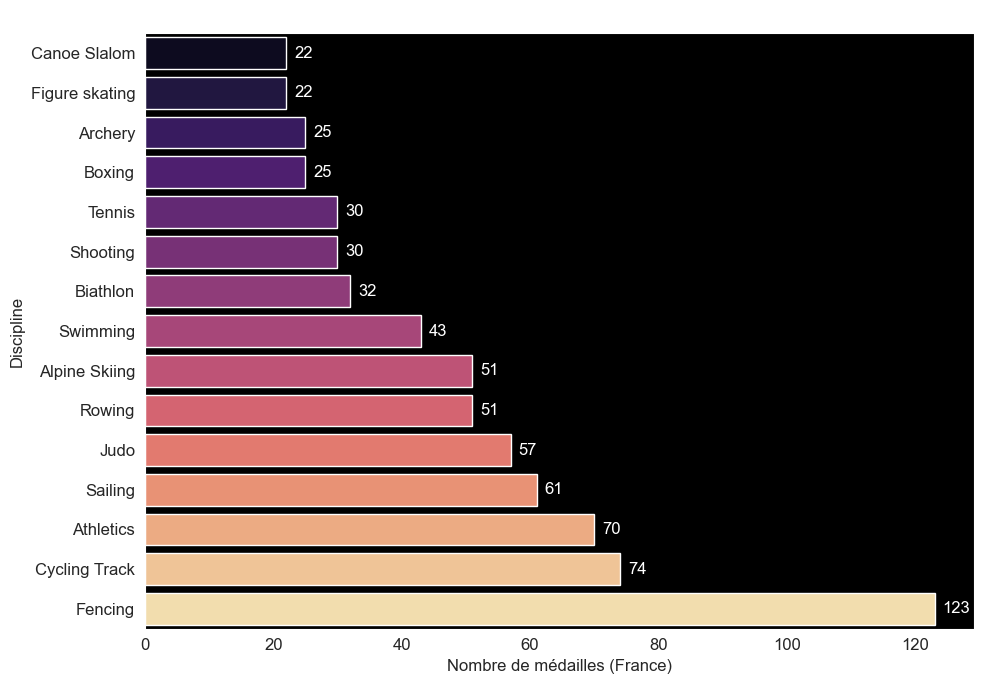

Top disciplines (France):


,discipline_title,medal_count
23,Fencing,123
16,Cycling Track,74
2,Athletics,70
38,Sailing,61
29,Judo,57
35,Rowing,51
0,Alpine Skiing,51
42,Swimming,43
4,Biathlon,32
39,Shooting,30


In [49]:
# Question 3 : spécialités sportives de la France - médailles par discipline
# Objectif : tracer un barplot des médailles remportées par la France par discipline
import matplotlib.pyplot as plt
import seaborn as sns
# s'assurer que df_medals existe
if 'df_medals' not in globals():
    raise RuntimeError('df_medals introuvable - exécutez les cellules de chargement des données dabord')
# Filtrer les médailles françaises (essayer plusieurs identifiants)
df_fr = df_medals.copy()
mask_fr = (
    (df_fr.get('country_name') == 'France') |
    (df_fr.get('country_code') == 'FR') |
    (df_fr.get('country_3_letter_code') == 'FRA')
)
df_fr = df_fr[mask_fr].copy()
# Si aucune ligne trouvée, afficher message
if df_fr.empty:
    print('Aucune médaille trouvée pour la France dans df_medals (vérifier les codes pays).')
else:
    # Normaliser le nom de discipline et compter
    df_fr['discipline_title'] = df_fr['discipline_title'].fillna('Unknown')
    by_disc = df_fr.groupby('discipline_title').size().rename('medal_count').reset_index().sort_values('medal_count', ascending=False)
    # garder top 15 pour la lisibilité
    top_n = 15
    top = by_disc.head(top_n).iloc[::-1]
    plt.figure(figsize=(10,7))
    sns.barplot(x='medal_count', y='discipline_title', data=top, palette='magma')
    plt.xlabel('Nombre de médailles (France)')
    plt.ylabel('Discipline')
    plt.title(f'Médailles remportées par la France par discipline - Top {top_n}')
    # ajouter annotations
    for i, row in enumerate(top.itertuples()):
        plt.text(row.medal_count + max(top['medal_count'])*0.01, i, str(int(row.medal_count)), va='center')
    plt.tight_layout()
    plt.show()
    # exposer le DataFrame pour usage ultérieur
    df_france_by_discipline = by_disc
    print('Top disciplines (France):')
    display(by_disc.head(20))

#### Question 4: Quelles sont les sports les plus dominants dans les JO au fil des ans ?

Top 20 disciplines (toutes années confondues) :


,discipline_title,medal_count
5,Athletics,3080
72,Swimming,1763
85,Wrestling,1356
57,Rowing,1072
14,Boxing,996
39,Gymnastics Artistic,979
61,Shooting,871
17,Canoe Sprint,799
60,Sailing,771
84,Weightlifting,679


<Figure size 1200x600 with 0 Axes>

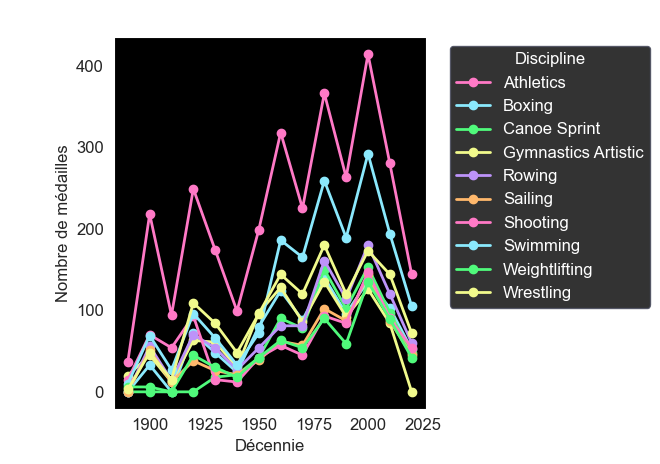

Disciplines avec la plus grande part de médailles (en %) :


,discipline_title,medal_count,share_pct
5,Athletics,3080,14.195511
72,Swimming,1763,8.125547
85,Wrestling,1356,6.249712
57,Rowing,1072,4.940775
14,Boxing,996,4.590496
39,Gymnastics Artistic,979,4.512145
61,Shooting,871,4.014380
17,Canoe Sprint,799,3.682537
60,Sailing,771,3.553487
84,Weightlifting,679,3.129465


In [50]:
# Question 4 : Quels sont les sports les plus dominants dans les JO au fil des ans ?
# Cette cellule calcule :
#  - le classement global des disciplines par nombre de médailles,
#  - l'évolution par décennie pour les top disciplines,
#  - une proposition de métrique de dominance (part de médailles).
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Préparer les données
m = df_medals.copy()
if 'game_year' not in m.columns and 'slug_game' in m.columns and 'df_hosts' in globals():
    m = m.merge(df_hosts[['game_slug','game_year']].drop_duplicates(), left_on='slug_game', right_on='game_slug', how='left')
m['discipline_title'] = m['discipline_title'].fillna('Unknown')
m['game_year'] = pd.to_numeric(m['game_year'], errors='coerce').astype('Int64')
# 1) Top disciplines globalement
global_counts = m.groupby('discipline_title').size().rename('medal_count').reset_index().sort_values('medal_count', ascending=False)
print('Top 20 disciplines (toutes années confondues) :')
display(global_counts.head(20))
# 2) Evolution par décennie
m = m.dropna(subset=['game_year']).copy()
m['decade'] = (m['game_year'] // 10 * 10).astype('Int64')
decade_counts = (m.groupby(['decade','discipline_title']).size().rename('medals').reset_index())
# tracer l'évolution des top 10 disciplines
top_disc = global_counts.head(10)['discipline_title'].tolist()
decade_top = decade_counts[decade_counts['discipline_title'].isin(top_disc)].copy()
pivot = decade_top.pivot(index='decade', columns='discipline_title', values='medals').fillna(0)
plt.figure(figsize=(12,6))
pivot.plot(kind='line', marker='o', linewidth=2)
plt.title('Évolution des médailles par décennie - Top disciplines')
plt.xlabel('Décennie')
plt.ylabel('Nombre de médailles')
plt.legend(title='Discipline', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()
# 3) Proposition de métrique de dominance : part des médailles globales par discipline
total_medals = global_counts['medal_count'].sum()
global_counts['share_pct'] = global_counts['medal_count'] / total_medals * 100
print('Disciplines avec la plus grande part de médailles (en %) :')
display(global_counts.head(15))

### 5.3 Question Bonus

#### Question Bonus: Y a-t-il une corrélation entre le nombre de médailles remportées et des facteurs économiques tel que le montant du Produit Intérieur Brut (PIB) ? Pour cela, vous pouvez `scraper` le tableau présent sur la page Web ci-dessus et avancez votre analyse ? Le tableau est spécifique à 2020. Vous pouvez avancer sur 2021-2022-2023.

Lancement de l'analyse Bonus : Médailles ↔ PIB (2020-2023)
Pays utilisés: 89, Corrélation (Pearson): 0.8266444360976497


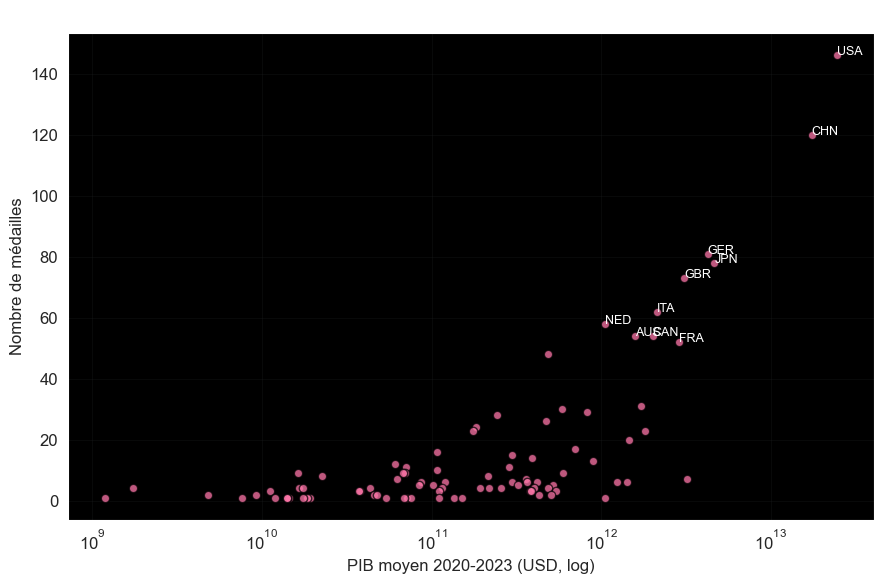

Corrélation (Pearson) calculée: 0.8266444360976497


,country_3_letter_code,medal_count,iso2,gdp_mean_2020_2023
90,USA,146,US,2.469072e+13
15,CHN,120,CN,1.744631e+13
33,GER,81,DE,4.244435e+12
47,JPN,78,JP,4.642212e+12
31,GBR,73,GB,3.081001e+12
44,ITA,62,IT,2.123840e+12
64,NED,58,NL,1.046984e+12
14,CAN,54,CA,2.010454e+12
2,AUS,54,AU,1.576016e+12
30,FRA,52,FR,2.865623e+12


In [ ]:
# Corrélation Médailles ↔ PIB (2020-2023)
# Cette cellule :
# - extrait l'année depuis `game_year` ou `slug_game` si nécessaire,
# - agrège les médailles par pays sur la fenêtre demandée,
# - convertit les codes (ISO3→ISO2) si besoin (via restcountries) avec cache,
# - récupère le PIB moyen 2020-2023 depuis World Bank (avec timeout et cache),
# - calcule la corrélation (Pearson) et affiche un nuage de points.

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import quote

# --- Helpers ---
def ensure_game_year(df):
    df = df.copy()
    if 'game_year' not in df.columns or df['game_year'].isnull().all():
        df['game_year'] = df['slug_game'].str.extract(r"(\d{4})")[0]
    df['game_year'] = pd.to_numeric(df['game_year'], errors='coerce').astype('Int64')
    return df

def medals_by_country(df_medals, years=None):
    m = df_medals.copy()
    m = ensure_game_year(m)
    if years is not None:
        if isinstance(years, int):
            years = [years]
        m = m[m['game_year'].isin(years)]
    # pick best key available
    if 'country_3_letter_code' in m.columns:
        key = 'country_3_letter_code'
    elif 'country_code' in m.columns:
        key = 'country_code'
    else:
        key = 'country_name'
    agg = m.dropna(subset=[key]).groupby(key).size().rename('medal_count').reset_index()
    agg = agg.sort_values('medal_count', ascending=False)
    return agg

# cache for iso conversions and GDP
_iso_cache = {}
_gdp_cache = {}

def iso3_to_iso2(iso3):
    if not isinstance(iso3, str):
        return None
    iso3 = iso3.strip()
    if iso3 in _iso_cache:
        return _iso_cache[iso3]
    try:
        r = requests.get(f'https://restcountries.com/v3.1/alpha/{quote(iso3)}', timeout=8)
        if r.status_code == 200:
            data = r.json()
            if isinstance(data, list) and len(data) > 0:
                iso2 = data[0].get('cca2')
                _iso_cache[iso3] = iso2
                return iso2
    except Exception:
        pass
    _iso_cache[iso3] = None
    return None

def fetch_gdp_iso2(iso2, start_year=2020, end_year=2023):
    if not iso2 or not isinstance(iso2, str):
        return None
    iso2 = iso2.strip().upper()
    key = f"{iso2}_{start_year}_{end_year}"
    if key in _gdp_cache:
        return _gdp_cache[key]
    try:
        url = f'https://api.worldbank.org/v2/country/{quote(iso2)}/indicator/NY.GDP.MKTP.CD?date={start_year}:{end_year}&format=json&per_page=100'
        r = requests.get(url, timeout=12)
        if r.status_code != 200:
            _gdp_cache[key] = None
            return None
        js = r.json()
        if not isinstance(js, list) or len(js) < 2:
            _gdp_cache[key] = None
            return None
        records = js[1]
        vals = [rec.get('value') for rec in records if rec.get('value') is not None]
        if not vals:
            _gdp_cache[key] = None
            return None
        mean_gdp = float(np.nanmean(vals))
        _gdp_cache[key] = mean_gdp
        return mean_gdp
    except Exception:
        _gdp_cache[key] = None
        return None


def run_gdp_medal_correlation(df_medals, years=[2020,2021,2022,2023], annotate_top=10):
    """Retourne (df_valid, corr) ou None si échec. Affiche graphique et tableau."""
    medals = medals_by_country(df_medals, years=years)
    if medals is None or medals.empty:
        print('Aucune agrégation de médailles pour les années demandées (vérifiez les colonnes game_year/slug_game).')
        return None

    # determine code type and convert to ISO2 where possible
    codes = medals.iloc[:,0].astype(str)
    iso2_list = []
    for code in codes:
        code = code.strip()
        if len(code) == 3:
            iso2 = iso3_to_iso2(code)
        elif len(code) == 2:
            iso2 = code.upper()
        else:
            # country names are not supported for automatic GDP fetch
            iso2 = None
        iso2_list.append(iso2)
    medals['iso2'] = iso2_list

    # fetch GDP for each iso2
    gdp_vals = []
    for iso2 in medals['iso2']:
        if iso2:
            g = fetch_gdp_iso2(iso2)
        else:
            g = None
        gdp_vals.append(g)
    medals['gdp_mean_2020_2023'] = gdp_vals

    df_valid = medals.dropna(subset=['gdp_mean_2020_2023']).copy()
    if df_valid.empty:
        print('Aucune donnée PIB disponible pour la jointure. Vérifiez la connectivité réseau et le format des codes pays (ISO2/ISO3).')
        return None

    # corr
    corr = df_valid['medal_count'].corr(df_valid['gdp_mean_2020_2023'])
    print(f'Pays utilisés: {len(df_valid)}, Corrélation (Pearson): {corr}')

    # plot
    plt.figure(figsize=(9,6))
    plt.scatter(df_valid['gdp_mean_2020_2023'], df_valid['medal_count'], alpha=0.75, color='#ff77aa', edgecolor='k')
    plt.xscale('log')
    plt.xlabel('PIB moyen 2020-2023 (USD, log)')
    plt.ylabel('Nombre de médailles')
    plt.title('Médailles vs PIB (2020-2023)')
    # annotate top countries by medal_count
    topn = df_valid.sort_values('medal_count', ascending=False).head(annotate_top)
    for _, r in topn.iterrows():
        label = str(r.iloc[0])
        plt.text(r['gdp_mean_2020_2023'], r['medal_count'], label, fontsize=9)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return df_valid, corr

# === Exécution ===
try:
    print('Lancement de l\'analyse Bonus : Médailles ↔ PIB (2020-2023)')
    res = run_gdp_medal_correlation(df_medals, years=[2020,2021,2022,2023])
    if res is None:
        print('Analyse non réalisée : pas de données PIB jointes (voir message précédent).')
    else:
        df_valid, corr = res
        print(f'Corrélation (Pearson) calculée: {corr}')
        display(df_valid.sort_values('medal_count', ascending=False).head(40))
except Exception as e:
    print('Erreur lors de l\'exécution du Bonus :', e)


Avec 89 pays inclus, la corrélation de Pearson entre le PIB moyen 2020–2023 et le nombre de médailles est d'environ 0,827, ce qui indique une forte relation positive : les pays au PIB plus élevé tendent à remporter davantage de médailles.